In [563]:
import gc
import numpy as np
import os
import re
import sys

import pandas as pd
import tensorflow_data_validation as tfdv

#VERSION = "20221025"
DATA_DIR = r"Z:\13.Data Science\Projects\2022_GI_Xsell\Data"
PROJECT_DIR = "../"
RAW_DATA_DIR = os.path.join(DATA_DIR, "raw")
PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "processed")
META_DATA_DIR = os.path.join(DATA_DIR, "meta_and_reference_data")
VER_1025_DIR = os.path.join(RAW_DATA_DIR, "20221025")
VER_1118_DIR = os.path.join(RAW_DATA_DIR, "20221118")
VER_1122_DIR = os.path.join(RAW_DATA_DIR, "20221122")
VER_1212_DIR = os.path.join(RAW_DATA_DIR, "20221212")
GI_DATA_DIR = os.path.join(RAW_DATA_DIR, "GI")
PA_DATA_DIR = os.path.join(GI_DATA_DIR, "Travel", "202210")
sys.path.insert(0, DATA_DIR)
sys.path.insert(0, PROJECT_DIR)

from datetime import datetime
from dateutil.relativedelta import relativedelta

# from src.utils.common import PLAN_TYPE_LST, WGP_LST, INFORCE_STATUS_LST, TRAVEL_SINGLE_MULTI_TRIP_DICT
# from src.utils.helper_function import find_plan_type, one_hot

In [564]:
pd.set_option('display.width', None)
pd.set_option('max_colwidth', None)
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [565]:
BASESTAT_FILE = os.path.join(PA_DATA_DIR, "basestat.parquet")
CLAMBASE_FILE = os.path.join(PA_DATA_DIR, "clambase_df.parquet")
PREMBASE_FILE = os.path.join(PA_DATA_DIR, "prembase.parquet")
CLIENT_DATA_MAPPING_FILE = os.path.join(PROCESSED_DATA_DIR, "processed_client_data.parquet")

## import basestat file


In [566]:
prembase_df = pd.read_parquet(BASESTAT_FILE)


In [567]:
# convert column CCDATE, TRANDATE to datetime at prembase_df
prembase_df["OCCDATE"] = pd.to_datetime(prembase_df["OCCDATE"], format="%Y%m%d")
prembase_df["CCDATE"] = pd.to_datetime(prembase_df["CCDATE"], format="%Y%m%d")
# prembase_df["TRANDATE"] = pd.to_datetime(prembase_df["TRANDATE"], format="%Y%m%d")
# strip contrnb 
prembase_df['contrnb'] = prembase_df['contrnb'].str.strip()
# strip COWNNUM
prembase_df['COWNNUM'] = prembase_df['COWNNUM'].str.strip()

In [568]:
prembase_df.sample(3)

,contrnb,CCDATE,RSKNO,DTEEFF,CNTTYPE,OCCDATE,COWNNUM,AGNTNUM,CNTBRANCH,autorenew,ZDMIND,bulk,bulk_name,nbrn,tranat,product,bulk_name1,CLTSEX,INSURED,ZPLANCDE,trlarea,znolive,plan1,duration,lastznolive,plan2,plan3,ChinaCard,EnhancedPA,duration_grp,producer,rmisagent,channel,lifeagent,product2,gap_trandate_ccdate,gap_trandate_ccdate_gp,znolive_gp,age_gp,loyalty,loyalty_cat,insage_smu,inssex_smu,insage_smu_gp,disc_gp,gwp,nwp,gep,nep,yduration,disc,ypol,ypol_actual,no_pol,no_rsk,commis,commis_n,nec,if_pol,if_rsk,ExpectedCost,TechnicalPremium,MarketingPremium,GWP_initial,APTP_gp,chgbal_g,chgbal_n,paymnt_g,paymnt_n,nb_clm,incur_g,incur_n,ultincur_n,ult_clm,lrg_incur_g,lrg_incur_n,lrg_ultincur,if_znolive,Agg_CA_nb_clm,Agg_EA_nb_clm,Agg_ME_nb_clm,Agg_PA_nb_clm,Agg_PB_nb_clm,Agg_TD_nb_clm,Agg_TP_nb_clm,Agg_CA_ultclm,Agg_EA_ultclm,Agg_ME_ultclm,Agg_PA_ultclm,Agg_PB_ultclm,Agg_TD_ultclm,Agg_TP_ultclm,Agg_CA_incur_g,Agg_EA_incur_g,Agg_ME_incur_g,Agg_PA_incur_g,Agg_PB_incur_g,Agg_TD_incur_g,Agg_TP_incur_g,Agg_CA_incur_n,Agg_EA_incur_n,Agg_ME_incur_n,Agg_PA_incur_n,Agg_PB_incur_n,Agg_TD_incur_n,Agg_TP_incur_n,Agg_CA_ultincur,Agg_EA_ultincur,Agg_ME_ultincur,Agg_PA_ultincur,Agg_PB_ultincur,Agg_TD_ultincur,Agg_TP_ultincur,period,total_yduration,no_znolive
4528201,25951165,2020-01-17,1.0,20200117.0,STQ,2020-01-17,2974640,E82391,20,0.0,N,N,N,NB,NWBS,Single Trip 2018,N,F,NaN,*X,X,1.0,Single,5.0,1.0,Asia,Standard,N,NA,3. 4-5 Days,HSBC - Dummy,637(SURANCE)-MBL,Banca - HSBC,0.0,TravelSurance - 2018,1.0,2. 1 to 5 days,1. 1 person,3. Age 31 - 40,-0.0,Single,NaN,NaN,NaN,2. Discount = 11% to 15%,25.12,24.94416,25.120000,24.944160,5.0,4.43,0.013689,1.0,1.0,1.0,7.54,7.54,7.540000,0.0,0.0,72.561298,169.170986,197.0,25.12,6. -5% to 5%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20200101.0,5.0,1.0
4936593,25982862,2022-01-21,2.0,20220121.0,STZ,2021-01-21,6032869,E82391,20,0.0,N,N,N,RN,CANC,Multi Trip 2018,N,M,NaN,*Y,Y,NaN,Annual,NaN,NaN,Worldwide,Basic,N,NA,Annual,HSBC - Dummy,637(SURANCE)-MBL,Banca - HSBC,0.0,TravelSurance - 2018,13.0,4. 11 to 15 days,1. 1 person,4. Age 41 - 50,1.0,1,NaN,NaN,NaN,0. No Discount,0.00,0.00000,0.000000,0.000000,0.0,0.00,0.000000,0.0,0.0,0.0,0.00,0.00,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.00,12. unknown,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20220101.0,0.0,0.0
4933790,25975000,2021-04-15,1.0,20210415.0,STZ,2020-04-15,2989311,E81403,20,0.0,N,N,N,RN,RNWL,Multi Trip 2018,N,M,NaN,*Z,Z,1.0,Annual,167.0,1.0,Worldwide,Standard,Y,NA,Annual,HSBC - Dummy,637(SURANCE)-RDP,Banca - HSBC,0.0,TravelSurance - 2018,13.0,4. 11 to 15 days,1. 1 person,7. Age 71 - 80,1.0,1,NaN,NaN,NaN,0. No Discount,0.00,0.00000,199.380822,198.403856,0.0,0.00,0.284736,0.0,0.0,0.0,0.00,0.00,59.815671,0.0,0.0,0.000000,0.000000,0.0,0.00,12. unknown,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20220101.0,0.0,0.0


In [759]:
list(prembase_df.columns)

['contrnb',
 'CCDATE',
 'RSKNO',
 'DTEEFF',
 'CNTTYPE',
 'OCCDATE',
 'COWNNUM',
 'AGNTNUM',
 'CNTBRANCH',
 'autorenew',
 'ZDMIND',
 'bulk',
 'bulk_name',
 'nbrn',
 'tranat',
 'product',
 'bulk_name1',
 'CLTSEX',
 'INSURED',
 'ZPLANCDE',
 'trlarea',
 'znolive',
 'plan1',
 'duration',
 'lastznolive',
 'plan2',
 'plan3',
 'ChinaCard',
 'EnhancedPA',
 'duration_grp',
 'producer',
 'rmisagent',
 'channel',
 'lifeagent',
 'product2',
 'gap_trandate_ccdate',
 'gap_trandate_ccdate_gp',
 'znolive_gp',
 'age_gp',
 'loyalty',
 'loyalty_cat',
 'insage_smu',
 'inssex_smu',
 'insage_smu_gp',
 'disc_gp',
 'gwp',
 'nwp',
 'gep',
 'nep',
 'yduration',
 'disc',
 'ypol',
 'ypol_actual',
 'no_pol',
 'no_rsk',
 'commis',
 'commis_n',
 'nec',
 'if_pol',
 'if_rsk',
 'ExpectedCost',
 'TechnicalPremium',
 'MarketingPremium',
 'GWP_initial',
 'APTP_gp',
 'chgbal_g',
 'chgbal_n',
 'paymnt_g',
 'paymnt_n',
 'nb_clm',
 'incur_g',
 'incur_n',
 'ultincur_n',
 'ult_clm',
 'lrg_incur_g',
 'lrg_incur_n',
 'lrg_ultincur

In [569]:
# get useful columns from base_df 
useful_prembase_df=prembase_df[['COWNNUM','contrnb','OCCDATE','CCDATE','channel','product','plan1','plan2','plan3','duration','duration_grp','age_gp','gwp','nb_clm','ult_clm','paymnt_g','period','if_pol','nbrn','CLTSEX']]
# show shape of useful_base_df
useful_prembase_df.shape


(5086231, 20)

In [570]:
# stip all string columns
useful_prembase_df['COWNNUM'] = useful_prembase_df['COWNNUM'].str.strip()
useful_prembase_df['contrnb'] = useful_prembase_df['contrnb'].str.strip()
useful_prembase_df['channel'] = useful_prembase_df['channel'].str.strip()
useful_prembase_df['product'] = useful_prembase_df['product'].str.strip()
useful_prembase_df['plan1'] = useful_prembase_df['plan1'].str.strip()
useful_prembase_df['age_gp'] = useful_prembase_df['age_gp'].str.strip()
# useful_prembase_df['period'] = useful_prembase_df['period'].str.strip()
# convert all time string to datetime
useful_prembase_df['OCCDATE'] = pd.to_datetime(useful_prembase_df['OCCDATE'], format="%Y%m%d")
useful_prembase_df['CCDATE'] = pd.to_datetime(useful_prembase_df['CCDATE'], format="%Y%m%d")
useful_prembase_df['period'] = pd.to_datetime(useful_prembase_df['CCDATE'], format="%Y%m%d")


C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_23712/4159339058.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useful_prembase_df['COWNNUM'] = useful_prembase_df['COWNNUM'].str.strip()
C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_23712/4159339058.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useful_prembase_df['contrnb'] = useful_prembase_df['contrnb'].str.strip()
C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_23712/4159339058.py:4: SettingWithCopyWarning: 
A value is trying to be s

In [571]:
# count how many unique channel for each contrnb
useful_prembase_df.groupby('contrnb')['channel'].nunique().sort_values(ascending=False)

contrnb
S5235781    2
Z1117919    2
Z1245193    2
Z0411986    2
Z1307920    2
           ..
95204115    0
95772871    0
95202631    0
95200924    0
95534405    0
Name: channel, Length: 2243681, dtype: int64

In [572]:
# count how many unique contrnb has more than 1 channel
useful_prembase_df.groupby('contrnb')['channel'].nunique().sort_values(ascending=False).value_counts()

1    2242717
0        806
2        158
Name: channel, dtype: int64

In [573]:
# show some rows with no channel
useful_prembase_df[useful_prembase_df['channel'].isnull()].sample(3)

,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age_gp,gwp,nb_clm,ult_clm,paymnt_g,period,if_pol,nbrn,CLTSEX
1520,None,93819209,NaT,NaT,NaN,None,NaN,None,None,NaN,NaN,NaN,0.0,1.0,1.0,0.00,NaT,0.0,NaN,NaN
2024,None,94487232,NaT,NaT,NaN,None,NaN,None,None,NaN,NaN,NaN,0.0,1.0,1.0,2034.88,NaT,0.0,NaN,NaN
534545,None,88150351,NaT,NaT,NaN,None,NaN,None,None,NaN,NaN,NaN,0.0,1.0,1.0,2652.36,NaT,0.0,NaN,NaN


In [574]:
# count percentage of unique contrnb has more than 1 channel
useful_prembase_df.groupby('contrnb')['channel'].nunique().sort_values(ascending=False).value_counts(normalize=True)

1    0.999570
0    0.000359
2    0.000070
Name: channel, dtype: float64

In [575]:
# show some row where contrnb has more than 1 channel
useful_prembase_df[useful_prembase_df['contrnb'].isin(useful_prembase_df.groupby('contrnb')['channel'].nunique().sort_values(ascending=False).index[useful_prembase_df.groupby('contrnb')['channel'].nunique().sort_values(ascending=False).values>1])]

,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age_gp,gwp,nb_clm,ult_clm,paymnt_g,period,if_pol,nbrn,CLTSEX
3873,0512615,S5027625,2011-07-06,2013-07-06,Agents & Broker,CITIPOINT Scheme,Annual,VIP,Insured Only,365.0,Annual,9. unknown,0.00,0.0,0.0,0.0,2013-07-06,0.0,RN,NaN
3874,0512615,S5027625,2011-07-06,2014-07-06,Agents & Broker,CITIPOINT Scheme,Annual,VIP,Insured Only,365.0,Annual,9. unknown,1755.00,0.0,0.0,0.0,2014-07-06,1.0,RN,NaN
4508,0626451,S5041631,2012-03-29,2013-03-29,LP,SmartTraveller (Annual),Annual,VIP,Insured Only,365.0,Annual,4. Age 41 - 50,0.00,0.0,0.0,0.0,2013-03-29,0.0,RN,NaN
4509,0626451,S5041631,2012-03-29,2014-03-29,LP,SmartTraveller (Annual),Annual,VIP,Insured Only,365.0,Annual,4. Age 41 - 50,1690.00,0.0,0.0,0.0,2014-03-29,1.0,RN,NaN
4715,0634656,S5045400,2012-05-16,2013-05-16,LP,SmartTraveller (Annual),Annual,VIP,Insured Only,365.0,Annual,9. unknown,0.00,0.0,0.0,0.0,2013-05-16,0.0,RN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5060915,1663509,Z1478738,2021-09-20,2022-09-20,Agents & Broker,UNICOVER OVERSEAS STUDENT INS,NaN,None,None,365.0,10. >180 Days,9. unknown,1138.50,0.0,0.0,0.0,2022-09-20,1.0,RN,M
5060916,1663509,Z1478738,2021-09-20,2021-09-20,LP,UNICOVER OVERSEAS STUDENT INS,NaN,None,None,365.0,10. >180 Days,9. unknown,0.00,1.0,1.0,3068.2,2021-09-20,0.0,NB,M
5060917,1663509,Z1478738,2021-09-20,2022-09-20,Agents & Broker,UNICOVER OVERSEAS STUDENT INS,NaN,None,None,365.0,10. >180 Days,9. unknown,569.25,0.0,0.0,0.0,2022-09-20,0.0,RN,M
5060918,1663509,Z1478738,2021-09-20,2021-09-20,LP,UNICOVER OVERSEAS STUDENT INS,NaN,None,None,365.0,10. >180 Days,9. unknown,0.00,0.0,0.0,0.0,2021-09-20,0.0,NB,M


In [576]:
265/(2421497+265)

0.00010942446037224137

# import client data

In [577]:
client_data_df = pd.read_parquet(CLIENT_DATA_MAPPING_FILE)

In [578]:
client_data_df.sample(10)

,CLNTNUM,VALIDFLAG,CLTTYPE,SECUITYNO,CLTSEX,OCCPCODE,CLTDOB,START_DATE,MARRYD,NATLTY,modified_SECUITYNO
834056,0850869,1,P,G414553(3),F,MGR,19690618.0,20150213.0,M,HK,G414553
4488474,2289884,1,P,B970098(1),M,None,19470825.0,20160614.0,None,HK,B970098
4066019,Q6425825,1,P,Y885507(0),F,UNKN,20021212.0,20070503.0,S,HK,Y885507
5039992,4030979,1,P,H141737(3),M,MANA,19540923.0,20220114.0,S,XXX,H141737
1303478,G8166434,1,P,Z164471(9),F,UNKN,19801130.0,99999999.0,None,None,Z164471
5906743,4079682,1,P,E748653(0),M,MANA,19620910.0,20200528.0,M,XXX,E748653
862974,H1362253,1,P,H051941(5),M,UNKN,19540721.0,99999999.0,M,None,H051941
790363,0807122,1,P,0807122,F,None,19960603.0,20140704.0,None,HK,0807122
2746299,N3037903,1,P,K803174(6),None,UNKN,99999999.0,99999999.0,None,None,K803174
482367,0495672,1,P,H118884(6),M,None,19600423.0,20100331.0,M,HK,H118884


In [579]:
# strip CLINTNUM SECUITYNO modified_SECUITYNO
client_data_df['CLNTNUM'] = client_data_df['CLNTNUM'].str.strip()
client_data_df['SECUITYNO'] = client_data_df['SECUITYNO'].str.strip()
client_data_df['modified_SECUITYNO'] = client_data_df['modified_SECUITYNO'].str.strip()



In [580]:
useful_client_data_df=client_data_df[['CLNTNUM','modified_SECUITYNO']]

In [581]:
print("prembase_df size before merge:", useful_prembase_df.shape)
#COWNNUM=client number 
# left join prembase_df with client_data_df, using column CLNTNUM from client_data_df and column COWNNUM from prembase_df as key
useful_prembase_w_client_df = useful_prembase_df.merge(useful_client_data_df, left_on="COWNNUM", right_on='CLNTNUM' ,how="left")

print("prembase_df size after merge:", useful_prembase_w_client_df.shape)

prembase_df size before merge: (5086231, 20)
prembase_df size after merge: (5086231, 22)


In [582]:
useful_prembase_w_client_df.sample(10)

,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age_gp,gwp,nb_clm,ult_clm,paymnt_g,period,if_pol,nbrn,CLTSEX,CLNTNUM,modified_SECUITYNO
2692273,2081693,25340722,2018-03-12,2018-03-12,Banca - HSBC,TravelSurance (single trip),Single,Area 1,Self Only,4.0,3. 4-5 Days,2. Age 17 - 30,15.66,0.0,0.0,0.0,2018-03-12,0.0,NB,F,2081693,R293726
1869908,2471638,25018140,2017-04-28,2017-04-28,Banca - HSBC,TravelSurance (single trip),Single,Area 1,Self Only,0.0,4. 6-7 Days,2. Age 17 - 30,133.28,0.0,0.0,0.0,2017-04-28,0.0,NB,F,2471638,R232435
4876049,1606902,Z1402969,2020-09-14,2020-09-14,LP,UNICOVER OVERSEAS STUDENT INS,NaN,None,None,NaN,10. >180 Days,2. Age 17 - 30,0.00,0.0,0.0,0.0,2020-09-14,0.0,NB,F,1606902,Y623731
3969520,2937357,25879697,2019-10-11,2019-10-11,Banca - HSBC,Single Trip 2018,Single,Asia,Basic,5.0,3. 4-5 Days,3. Age 31 - 40,34.88,0.0,0.0,0.0,2019-10-11,0.0,NB,F,2937357,Z112990
947367,2139781,24686183,2016-05-11,2016-05-11,Banca - HSBC,TravelSurance (single trip),Single,Area 1,Self Only,3.0,2. 1-3 Days,3. Age 31 - 40,13.80,0.0,0.0,0.0,2016-05-11,0.0,NB,F,2139781,K501280
2798088,2656971,25396459,2018-05-02,2018-05-02,Banca - HSBC,TravelSurance (single trip),Single,Area 1,Parents,0.0,6. 11-14 Days,3. Age 31 - 40,372.47,0.0,0.0,0.0,2018-05-02,0.0,NB,M,2656971,Z372655
24108,0390443,S5119553,2014-03-12,2014-03-12,Agents & Broker,SmartTraveller (Single),Single,VIP,Insured & Family,8.0,5. 8-10 Days,3. Age 31 - 40,576.00,0.0,0.0,0.0,2014-03-12,0.0,NB,F,0390443,K259783
4629260,1403716,S5375505,2019-03-15,2019-03-15,Agents & Broker,SmartTraveller (Annual),Annual,Classic,Insured & Family,366.0,Annual,3. Age 31 - 40,0.00,0.0,0.0,0.0,2019-03-15,0.0,NB,M,1403716,M804194
673387,0767527,Z0623529,2014-01-30,2015-01-30,Agents & Broker,SmartTraveller (Annual),Annual,VIP,Insured Only,365.0,Annual,4. Age 41 - 50,3510.00,0.0,0.0,0.0,2015-01-30,0.0,RN,M,0767527,R927235
4061458,2962755,25928617,2019-12-31,2019-12-31,Banca - HSBC,Single Trip 2018,Single,Asia,Standard,6.0,4. 6-7 Days,2. Age 17 - 30,61.53,0.0,0.0,0.0,2019-12-31,1.0,NB,F,2962755,Y076861


In [583]:
# see how many rows where modified_SECUITYNO is NaN, anc value count channel

print(useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()].shape)

(52134, 22)


In [584]:
# see how many unique clients where modified_SECUITYNO is NaN
print(useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]["COWNNUM"].nunique())

32227


In [585]:
# show some rows

In [586]:
# see how many rows where CLNTNUM is NaN, 
print(useful_prembase_w_client_df[useful_prembase_w_client_df["CLNTNUM"].isna()].shape)

(52134, 22)


In [587]:
# number of unique COWNNUM in useful_prembase_w_client_df
print(useful_prembase_w_client_df['COWNNUM'].nunique())

1432212


In [588]:
# see how many unique COWNNUM where modified_SECUITYNO is NaN
print(useful_prembase_w_client_df[useful_prembase_w_client_df["CLNTNUM"].isna()]["COWNNUM"].nunique())

32227


In [589]:
PERCENTAGE_OF_UNIQUE_CLIENTS_WITHOUT_ID=(32227/1499865)*100
PERCENTAGE_OF_UNIQUE_CLIENTS_WITHOUT_ID

2.148660046070813

In [590]:
# show some rows where CLNTNUM is NaN
useful_prembase_w_client_df[useful_prembase_w_client_df["CLNTNUM"].isna()].sample(10)

,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age_gp,gwp,nb_clm,ult_clm,paymnt_g,period,if_pol,nbrn,CLTSEX,CLNTNUM,modified_SECUITYNO
4965385,6087038,25999811,2022-08-16,2022-08-16,Banca - HSBC,Single Trip 2018,Single,Asia,Basic,10.0,5. 8-10 Days,4. Age 41 - 50,226.14,0.0,0.0,0.00,2022-08-16,0.0,NB,M,NaN,NaN
4966181,6087733,26000210,2022-09-07,2022-09-07,Banca - HSBC,Single Trip 2018,Single,Worldwide,Standard,3.0,2. 1-3 Days,2. Age 17 - 30,210.25,0.0,0.0,0.00,2022-09-07,0.0,NB,M,NaN,NaN
4974736,6093968,26004485,2022-10-06,2022-10-06,Banca - HSBC,Multi Trip 2018,Annual,Worldwide,Basic,365.0,Annual,6. Age 61 - 70,217.46,0.0,0.0,0.00,2022-10-06,1.0,NB,F,NaN,NaN
5048053,1731024,Z1387126,2022-09-30,2022-09-30,AXA Online Direct,SmartTraveller Plus (Single),Single,Economy,Insured Only,9.0,5. 8-10 Days,6. Age 61 - 70,492.15,0.0,0.0,0.00,2022-09-30,0.0,NB,M,NaN,NaN
4968586,6089988,26001418,2022-10-03,2022-10-03,Banca - HSBC,Multi Trip 2018,Annual,Worldwide,Standard,365.0,Annual,6. Age 61 - 70,503.69,0.0,0.0,0.00,2022-10-03,1.0,NB,F,NaN,NaN
4971403,6092235,26002821,2022-10-08,2022-10-08,Banca - HSBC,Single Trip 2018,Single,Asia,Basic,8.0,5. 8-10 Days,5. Age 51 - 60,323.97,0.0,0.0,0.00,2022-10-08,0.0,NB,F,NaN,NaN
5044395,1722719,Z1383633,2022-08-13,2022-08-13,LP,SmartTraveller Plus (Single),Single,Basic,Insured Only,141.0,9. 61-180 Days,2. Age 17 - 30,1773.90,0.0,0.0,0.00,2022-08-13,1.0,NB,F,NaN,NaN
5076461,1735579,Z1642469,2022-10-19,2022-10-19,AXA Online Direct,SmartTraveller Plus (Single),Single,Superior,Insured Only,33.0,8. 31-60 Days,7. Age 71 - 80,776.90,0.0,0.0,0.00,2022-10-19,1.0,NB,M,NaN,NaN
4961692,6083364,25996446,2022-07-18,2022-07-18,Banca - HSBC,Multi Trip 2018,Annual,Worldwide,Basic,365.0,Annual,5. Age 51 - 60,217.46,0.0,0.0,0.00,2022-07-18,1.0,NB,NaN,NaN,NaN
5043218,1719713,Z1382514,2022-08-18,2022-08-18,AXA Online Direct,SmartTraveller Plus (Single),Single,Superior,Insured Only,5.0,3. 4-5 Days,2. Age 17 - 30,174.00,1.0,1.0,962.76,2022-08-18,0.0,NB,M,NaN,NaN


In [591]:
# see how many channels where modified_SECUITYNO is NaN
print(useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]["channel"].value_counts())

Banca - HSBC          22618
AXA Online Direct     12446
Agents & Broker        6971
LP                     6633
Citi                    284
JLT (OSC)               273
AXA Offline Direct       40
Name: channel, dtype: int64


In [592]:
# count min and mix of the OCCDATE of "useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]"
print(useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]["OCCDATE"].min())
# useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]
print(useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]["OCCDATE"].max())

1998-07-01 00:00:00
2023-01-23 00:00:00


In [593]:
print(useful_prembase_w_client_df[useful_prembase_w_client_df["modified_SECUITYNO"].isna()]["product"].value_counts())

SmartTraveller Plus (Single)                 17591
Single Trip 2018                             15184
UNICOVER OVERSEAS STUDENT INS                 5493
Multi Trip 2018                               4624
SmartTraveller Plus (Annual)                  3227
Overseas StudySurance                         2796
SmartTraveller- Citi                           284
SmartTraveller (Single)                         24
SmartTraveller (Annual)                         11
Group Biz Travel                                 9
MultiTrip TravelSurance (Monthly payment)        8
Supreme Travel                                   8
MultiTrip TravelSurance (Annual)                 4
BUSINESS TRAVELCARE                              2
Name: product, dtype: int64


# drop useless rows

In [594]:
# drop rows where modified_SECUITYNO is NaN as the percentage only 2.14
useful_prembase_w_client_df = useful_prembase_w_client_df.dropna(subset=["modified_SECUITYNO"])

In [595]:
# see how many rows where COWNNUM is different from CLNTNUM
print(useful_prembase_w_client_df[useful_prembase_w_client_df["COWNNUM"] != useful_prembase_w_client_df["CLNTNUM"]].shape)

(0, 22)


In [596]:
DUMMY_ID=['unknown','A123456','F123456']
#drop if modified_SECUITYNO is in DUMMY_ID
useful_prembase_w_client_df = useful_prembase_w_client_df[~useful_prembase_w_client_df["modified_SECUITYNO"].isin(DUMMY_ID)]




In [597]:
# drop the column CLNTNUM as duplicate with COWNNUM
useful_prembase_w_client_df = useful_prembase_w_client_df.drop(columns=["CLNTNUM"])

In [598]:
useful_prembase_w_client_df.sample(10)


,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age_gp,gwp,nb_clm,ult_clm,paymnt_g,period,if_pol,nbrn,CLTSEX,modified_SECUITYNO
710218,2133829,24449197,2015-10-09,2016-10-09,Banca - HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,3. Age 31 - 40,1125.74,0.0,0.0,0.0,2016-10-09,0.0,RN,M,R930849
3807542,2872426,25791646,2019-06-19,2019-06-19,Banca - HSBC,Single Trip 2018,Single,Asia,Basic,8.0,5. 8-10 Days,2. Age 17 - 30,29.45,0.0,0.0,0.0,2019-06-19,0.0,NB,M,Y602222
4241108,1488911,S5437967,2019-08-24,2019-08-24,LP,SmartTraveller (Single),Single,VIP,Insured Only,8.0,5. 8-10 Days,4. Age 41 - 50,506.00,1.0,1.0,1480.0,2019-08-24,0.0,NB,M,G486570
2297058,H8724539,74800548,2001-06-01,2017-10-01,Banca - HSBC,MultiTrip TravelSurance (Monthly payment),Annual,Area 2,Self Only,0.0,Annual,5. Age 51 - 60,140.25,0.0,0.0,0.0,2017-10-01,0.0,HB,U,Y029582
2679242,2213283,25334117,2018-02-15,2018-02-15,Banca - HSBC,TravelSurance (single trip),Single,Area 1,Self Only,0.0,7. 15-30 Days,3. Age 31 - 40,303.70,0.0,0.0,0.0,2018-02-15,0.0,NB,M,K726011
2296619,H6312076,74445932,2001-03-05,2017-01-05,Banca - HSBC,MultiTrip TravelSurance (Monthly payment),Annual,Area 2,Self Only,0.0,Annual,5. Age 51 - 60,0.00,0.0,0.0,0.0,2017-01-05,0.0,HB,M,E927721
2455842,1107409,Z0949081,2017-07-30,2017-07-30,LP,SmartTraveller (Single),Single,VIP,Insured Only,6.0,4. 6-7 Days,3. Age 31 - 40,448.00,1.0,1.0,1200.0,2017-07-30,0.0,NB,F,Z229163
77929,0648185,S5154494,2014-11-03,2014-11-03,LP,SmartTraveller (Single),Single,VIP,Insured Only,4.0,3. 4-5 Days,3. Age 31 - 40,193.00,0.0,0.0,0.0,2014-11-03,0.0,NB,F,Z167702
2333974,M2194729,99431244,2014-07-01,2017-07-01,Banca - HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,NaN,Annual,6. Age 61 - 70,283.80,0.0,0.0,0.0,2017-07-01,1.0,HB,F,P196085
580588,0571746,S5172300,2015-03-19,2015-03-19,Agents & Broker,SmartTraveller (Single),Single,VIP,Insured Only,4.0,3. 4-5 Days,3. Age 31 - 40,170.00,0.0,0.0,0.0,2015-03-19,0.0,NB,F,K833824


# Read Clambase

In [599]:
# clambase_df = pd.read_parquet(CLAMBASE_FILE)


In [600]:
# show some rows where paymnt_n and paymnt_g is 0
# clambase_df[(clambase_df['paymnt_n']!=0) & (clambase_df['paymnt_g']!=0)].sample(10)

In [601]:
# show only colume 'CLAIM' ,'CLSTAT','CCDATE' in claim base
# useful_clambase_df=clambase_df[['CLAIM','CCDATE','contrnb','DATREP','paymnt_n','paymnt_g']]
# useful_clambase_df


In [602]:
# # convert CCDATE and DATREP to datetime
# useful_clambase_df['CCDATE'] = pd.to_datetime(useful_clambase_df['CCDATE'], format='%Y%m%d')
# useful_clambase_df['DATREP'] = pd.to_datetime(useful_clambase_df['DATREP'], format='%Y%m%d')

In [603]:
# # strip CLAIM,contrnb
# useful_clambase_df['CLAIM'] = useful_clambase_df['CLAIM'].str.strip()
# useful_clambase_df['contrnb'] = useful_clambase_df['contrnb'].str.strip()

In [604]:
# # see if there's any contrnb in useful_clambase_df that is not in prembase_df
# # print(useful_clambase_df[~useful_clambase_df["contrnb"].isin(prembase_df["contrnb"])].shape)

# print(useful_clambase_df[~useful_clambase_df["contrnb"].isin(useful_prembase_df["contrnb"])]['contrnb'].nunique())

# ###why????????

In [605]:
# # show all unique contrnb in useful_clambase_df that is not in useful_prembase_w_client_df
# useful_clambase_df[~useful_clambase_df["contrnb"].isin(useful_prembase_df["contrnb"])]

In [606]:
# # check if contrnb = 00453021 is in prembase_df
# print(useful_prembase_df[useful_prembase_df["contrnb"] == "00453021"].shape)

In [607]:
# print("clambase_df shape:", useful_clambase_df.shape)
# # drop all contrnb in useful_clambase_df that is not in useful_prembase_w_client_df
# useful_clambase_drop_not_in_usefulprembase = useful_clambase_df[useful_clambase_df["contrnb"].isin(useful_prembase_w_client_df["contrnb"])]


# print("clambase_df shape:", useful_clambase_drop_not_in_usefulprembase.shape)

In [608]:
# useful_clambase_drop_not_in_usefulprembase.shape

In [609]:
# # see if there's any unique contrnb in useful_clambase_drop_not_in_usefulprembase that is not in useful_prembase_w_client_df
# useful_clambase_drop_not_in_usefulprembase[~useful_clambase_drop_not_in_usefulprembase["contrnb"].isin(useful_prembase_w_client_df["contrnb"])]['contrnb'].nunique()


In [610]:
# print("clambase_df shape:", clambase_df.shape)
# print("number of policies:", clambase_df['contrnb'].nunique())

In [611]:
# useful_prembase_w_client_df.shape

In [612]:
# # merge useful_clambase_drop_not_in_usefulprembase with useful_prembase_w_client_df on contrnb only
# useful_prembase_w_client_w_clambase_df = pd.merge(useful_prembase_w_client_df, useful_clambase_drop_not_in_usefulprembase, on=['contrnb'], how='left')
# useful_prembase_w_client_w_clambase_df.shape

In [613]:
useful_prembase_w_client_w_clambase_df=useful_prembase_w_client_df

# change df name to useful_PCC

In [614]:
usefull_PCC=useful_prembase_w_client_w_clambase_df

In [615]:
usefull_PCC

,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age_gp,gwp,nb_clm,ult_clm,paymnt_g,period,if_pol,nbrn,CLTSEX,modified_SECUITYNO
5,N5245611,00325286,2011-12-24,2011-12-24,Banca - HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,2. Age 17 - 30,0.0,0.0,0.0,0.0,2011-12-24,0.0,NaN,F,R936984
7,N5245611,00325286,2011-12-24,2011-12-24,Banca - HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,2. Age 17 - 30,0.0,0.0,0.0,0.0,2011-12-24,0.0,NaN,F,R936984
13,N5551848,00358200,2012-02-14,2012-02-14,Banca - HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,535.0,Annual,2. Age 17 - 30,0.0,0.0,0.0,0.0,2012-02-14,1.0,NaN,M,R945944
14,N5551848,00358200,2012-02-14,2012-02-14,Banca - HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,2. Age 17 - 30,0.0,0.0,0.0,0.0,2012-02-14,0.0,NaN,M,R945944
17,N5598979,00363542,2012-02-22,2012-02-22,Banca - HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,1461.0,Annual,3. Age 31 - 40,0.0,0.0,0.0,0.0,2012-02-22,1.0,NaN,M,K734101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5086225,0784814,Z1942594,2022-10-26,2022-10-26,Agents & Broker,SmartTraveller Plus (Single),Single,Prestige,Insured Only,9.0,5. 8-10 Days,9. unknown,410.0,0.0,0.0,0.0,2022-10-26,1.0,NB,NaN,1434619
5086226,0516730,Z1942629,2022-10-25,2022-10-25,Agents & Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,6. Age 61 - 70,394.0,0.0,0.0,0.0,2022-10-25,1.0,NB,M,E478085
5086228,1046004,Z1942637,2022-11-04,2022-11-04,Agents & Broker,SmartTraveller (Single),Single,Specified Countries,Insured Only,8.0,5. 8-10 Days,6. Age 61 - 70,196.0,0.0,0.0,0.0,2022-11-04,0.0,NB,NaN,D241066
5086229,0361142,Z1942650,2022-10-25,2022-10-25,Agents & Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,4. Age 41 - 50,394.0,0.0,0.0,0.0,2022-10-25,1.0,NB,M,K957229


In [616]:
print(usefull_PCC.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4982859 entries, 5 to 5086230
Data columns (total 21 columns):
 #   Column              Dtype         
---  ------              -----         
 0   COWNNUM             object        
 1   contrnb             object        
 2   OCCDATE             datetime64[ns]
 3   CCDATE              datetime64[ns]
 4   channel             object        
 5   product             object        
 6   plan1               object        
 7   plan2               object        
 8   plan3               object        
 9   duration            float64       
 10  duration_grp        category      
 11  age_gp              object        
 12  gwp                 float64       
 13  nb_clm              float64       
 14  ult_clm             float64       
 15  paymnt_g            float64       
 16  period              datetime64[ns]
 17  if_pol              float64       
 18  nbrn                category      
 19  CLTSEX              category      
 20  mo

# Update channel names

In [617]:
modi_channels={
    'Banca - HSBC':'HSBC',
    'Agents & Broker':'Broker',
    'AXA Online Direct':'AXA Direct',
    'AXA Offline Direct':'AXA Direct',
    'LP':'Life Agent',
    'Citi':'others',
    'JLT (OSC)': 'others'
}

In [618]:
# strip the space in the column 'channel' in usefull_PCC
usefull_PCC['channel'] = usefull_PCC['channel'].str.strip()
#replace the value in the column "channel" with the value in the dictionary "modi_channels"
usefull_PCC['channel']=usefull_PCC['channel'].map(modi_channels)

In [619]:
ch=['HSBC','Broker','AXA Direct','Live Agent','others']

In [620]:
#generate a new DF named "By_Channel" , which has columns name 'HSBC','Broker','AXA Direct','Live Agent','others'
By_Channel = pd.DataFrame(columns=['HSBC','Broker','AXA Direct','Live Agent','others'])

# Update duration and plan type

In [621]:
# show all unqiue values in the column 'channel'
print(usefull_PCC['plan1'].unique())
print(usefull_PCC['channel'].unique())
print(usefull_PCC['product'].unique())

['Annual' nan 'Single']
['HSBC' 'Broker' 'Life Agent' 'AXA Direct' 'others']
['MultiTrip TravelSurance (Annual)'
 'MultiTrip TravelSurance (Monthly payment)' 'BUSINESS TRAVELCARE'
 'TravelSurance (single trip)' 'SmartTraveller (Annual)'
 'CITIPOINT Scheme' 'SmartTraveller (Single)' 'JLT Travel'
 'UNICOVER OVERSEAS STUDENT INS' 'Group Biz Travel' 'Supreme Travel'
 'GROUP TRAVEL COVER' 'SmartTraveller- Citi' 'Single Trip 2018'
 'Multi Trip 2018' 'AON Scheme' 'SmartTraveller Plus (Single)'
 'SmartTraveller Plus (Annual)' 'Overseas StudySurance']


In [622]:
# change all 'Unknown' in the column 'plan1' to NaN
usefull_PCC['plan1'] = usefull_PCC['plan1'].replace('Unknown', np.nan)

In [623]:
TRAVEL_SINGLE_MULTI_TRIP_DICT = {
    "AON Scheme": "multi",
    "AirAsia Travel": "single",
    "BUSINESS TRAVELCARE": "single",
    "CITIPOINT Scheme": "single",
    "Extrasure": "single",
    "GROUP TRAVEL COVER": "multi",
    "Group Biz Travel": "multi",
    "ICBC Scheme": "single",
    "JLT Travel": "single",
    "Multi Trip 2018": "multi",
    "MultiTrip TravelSurance (Annual)": "multi",
    "MultiTrip TravelSurance (Monthly payment)": "multi",
    "Overseas StudySurance": "single",
    "Single Trip 2018": "single",
    "SmartTraveller (Annual)": "multi",
    "SmartTraveller (Single)": "single",
    "SmartTraveller Plus (Annual)": "multi",
    "SmartTraveller Plus (Single)": "single",
    "SmartTraveller- Citi": "single",
    "Supreme Travel": "single",
    "TravelSurance (single trip)": "single",
    "UNICOVER OVERSEAS STUDENT INS": "single"
}

TRAVEL_DURATION_LENGTH_DICT = {
    "AON Scheme": "year",
    "AirAsia Travel": "month",
    "BUSINESS TRAVELCARE": "year",
    "CITIPOINT Scheme": "week",
    "Extrasure": "month",
    "GROUP TRAVEL COVER": "year",
    "Group Biz Travel": "year",
    "ICBC Scheme": "year",
    "JLT Travel": "week",
    "Multi Trip 2018": "year",
    "MultiTrip TravelSurance (Annual)": "year",
    "MultiTrip TravelSurance (Monthly payment)": "month",
    "Overseas StudySurance": "year",
    "Single Trip 2018": "week",
    "SmartTraveller (Annual)": "year",
    "SmartTraveller (Single)": "week",
    "SmartTraveller Plus (Annual)": "year",
    "SmartTraveller Plus (Single)": "week",
    "SmartTraveller- Citi": "week",
    "Supreme Travel": "year",
    "TravelSurance (single trip)": "week",
    "UNICOVER OVERSEAS STUDENT INS": "year",
}

plan1={
    'single': 'single',
    'Annual': 'Annual',
    'Annual/Over 30 Days': 'Annual'
}

In [624]:
# create a new column 'Single/Annual' in usefull_PCC using column 'plan1' and dictionary 'plan1'
usefull_PCC['Single/Annual'] = usefull_PCC['plan1'].map(plan1)


# Add new col named OCCYEAR

In [625]:
# add a new col named occyear from OCCDATE
usefull_PCC['OCCYEAR'] = pd.DatetimeIndex(usefull_PCC['OCCDATE']).year
# add a new col named CCYEAR from CCDATE
usefull_PCC['CCYEAR'] = pd.DatetimeIndex(usefull_PCC['CCDATE']).year


# Add new col names TimeRange

In [626]:
# PreCovid, which is a time range from 20170101- 20220230
# Covid, which is a time range from 20200301- 20220630
# PostCovid, which is a time range from 20220701- Present


In [627]:
# convert the type of column 'OCCDATE' to datetime
usefull_PCC['OCCDATE'] = pd.to_datetime(usefull_PCC['OCCDATE'], format='%Y%m%d')

In [628]:
# if the time range of OCCDATE is between 20170101- 20220230, then the value of the new column 'TimeRange' is 'PreCovid'
# if the time range of OCCDATE is between 20200301- 20220630, then the value of the new column 'TimeRange' is 'Covid'
# if the time range of OCCDATE is between 20220701- Present, then the value of the new column 'TimeRange' is 'PostCovid'
usefull_PCC['TimeRange'] = np.where(usefull_PCC['OCCDATE'] < '2020-03-01', '1.PreCovid', np.where(usefull_PCC['OCCDATE'] < '2022-07-01', '2.Covid', '3.PostCovid'))




In [629]:
# To varify the above cell
# show rows where OCCDATE less then 2020-03-01 then count unique TimeRange
usefull_PCC[usefull_PCC['OCCDATE'] < '2020-03-01']['TimeRange'].value_counts()

1.PreCovid    4827169
Name: TimeRange, dtype: int64

In [630]:
# create a new column 'TimeRange' in usefull_PCC using column 'OCCDATE' 

# Filter with 3 Dimensions

In [631]:
F_usefull_PCC=usefull_PCC

In [632]:
# get only rows greater then 20170101
F_usefull_PCC = usefull_PCC[usefull_PCC['OCCDATE'] > '20170101']

# Numbers


## Client Count

In [633]:
# count number of unique values in the column 'COWNNUM' 
F_usefull_PCC['modified_SECUITYNO'].nunique()

529267

In [634]:
# count number of  unique policies in the column 'contrnb'
F_usefull_PCC['contrnb'].nunique()

1402932

In [635]:
# group by Clients ID and count the number of unique policies in each group
F_usefull_PCC.groupby('modified_SECUITYNO')['contrnb'].nunique().sort_values(ascending=False)

modified_SECUITYNO
K780087      154
0645101      118
1987044       89
C431724       79
D404459       73
            ... 
K851110        1
K851084        1
K851077        1
K851075        1
ZA1961293      1
Name: contrnb, Length: 529267, dtype: int64

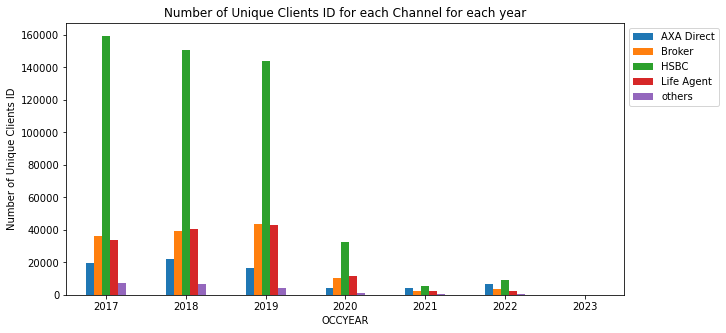

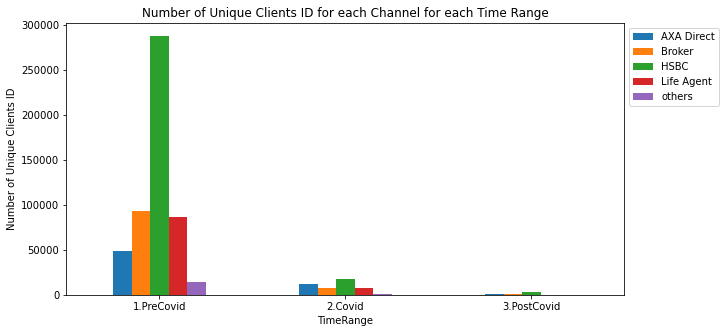

In [636]:
import matplotlib.pyplot as plt
# plot a graph of unique COWNNUM for each Channel for each year and show the number on the graph
F_usefull_PCC.groupby(['OCCYEAR','channel'])['modified_SECUITYNO'].nunique().unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# set Y axis as Number of Unique Clients ID
plt.ylabel('Number of Unique Clients ID')
# add title to the graph
plt.title('Number of Unique Clients ID for each Channel for each year')
plt.show()

# plot a graph of unique COWNNUM for each Channel for each year and show the number on the graph
F_usefull_PCC.groupby(['TimeRange','channel'])['modified_SECUITYNO'].nunique().unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# set Y axis as Number of Unique Clients ID
plt.ylabel('Number of Unique Clients ID')
# add title to the graph
plt.title('Number of Unique Clients ID for each Channel for each Time Range')
plt.show()




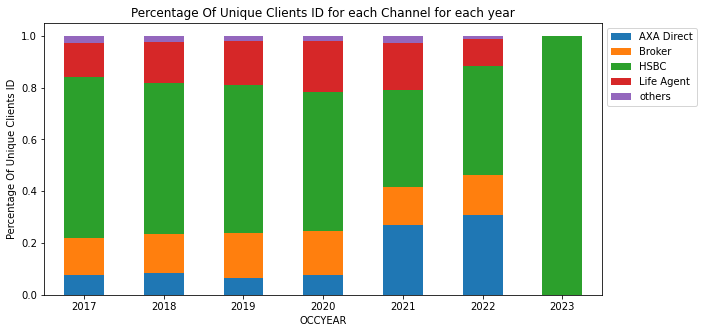

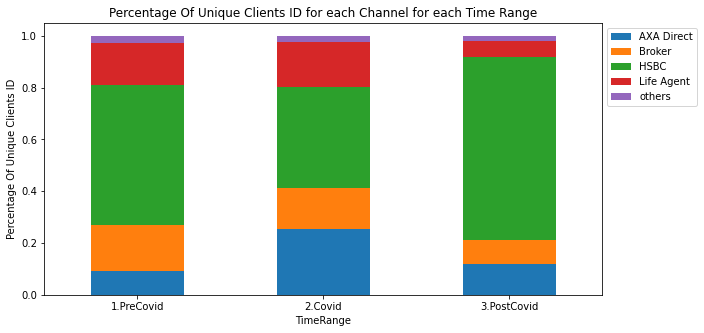

In [637]:
# plot a stacked column percentage chart of unique COWNNUM for each Channel for each year and show the number on the graph and scale to the same hight
F_usefull_PCC.groupby(['OCCYEAR','channel'])['modified_SECUITYNO'].nunique().unstack().apply(lambda x: x/x.sum(), axis=1).plot(kind='bar',stacked=True,figsize=(10,5),rot=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
#set y axis as Percentage Of Unique Clients ID
plt.ylabel('Percentage Of Unique Clients ID')
# add title
plt.title('Percentage Of Unique Clients ID for each Channel for each year')
plt.show()


# plot a stacked column percentage chart of unique COWNNUM for each Channel for each year and show the number on the graph and scale to the same hight
F_usefull_PCC.groupby(['TimeRange','channel'])['modified_SECUITYNO'].nunique().unstack().apply(lambda x: x/x.sum(), axis=1).plot(kind='bar',stacked=True,figsize=(10,5),rot=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
#set y axis as Percentage Of Unique Clients ID
plt.ylabel('Percentage Of Unique Clients ID')
# add title
plt.title('Percentage Of Unique Clients ID for each Channel for each Time Range')
plt.show()



In [638]:
# generate a df of unique COWNNUM for each Channel for each year
df =F_usefull_PCC.groupby(['OCCYEAR','channel'])['modified_SECUITYNO'].nunique().unstack()
df

channel,AXA Direct,Broker,HSBC,Life Agent,others
OCCYEAR,,,,,
2017,19476.0,36286.0,159318.0,33683.0,7415.0
2018,22298.0,39063.0,150911.0,40737.0,6487.0
2019,16262.0,43782.0,144079.0,42673.0,4483.0
2020,4483.0,10328.0,32301.0,11765.0,1169.0
2021,3881.0,2090.0,5387.0,2587.0,376.0
2022,6706.0,3276.0,9119.0,2296.0,253.0
2023,NaN,NaN,11.0,NaN,NaN


In [639]:
# AXA vs HSBC vs Others
# have agent vs no agent

## Policy Count


In [640]:
# count number of  unique policies in the column 'contrnb'
F_usefull_PCC['contrnb'].nunique()

1402932

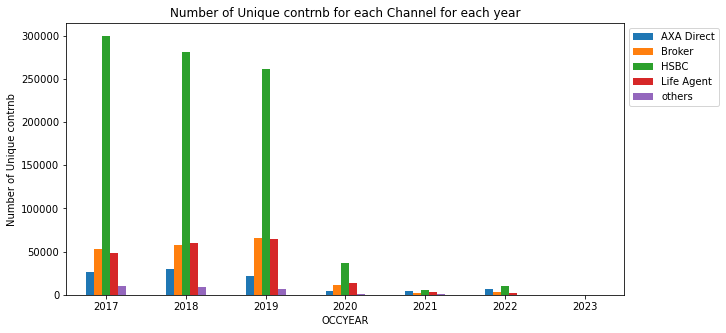

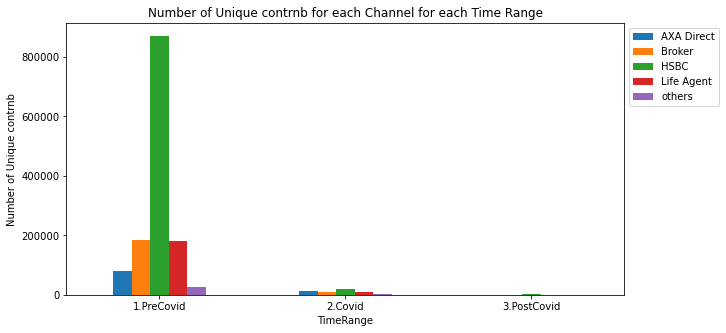

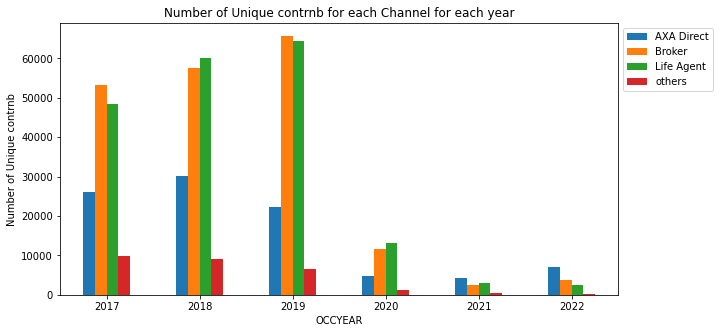

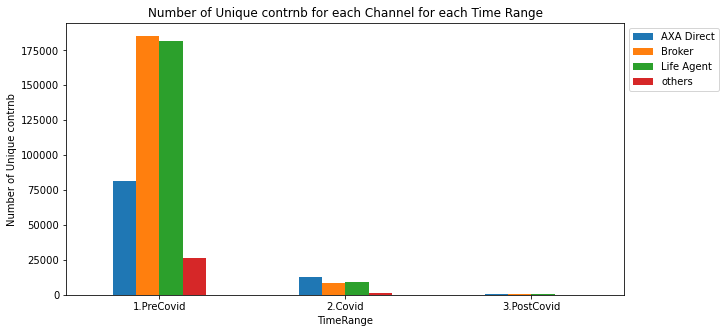

In [641]:
# plot a graph of unique contrnb for each Channel for each year and show the number on the graph
F_usefull_PCC.groupby(['OCCYEAR','channel'])['contrnb'].nunique().unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# set Y axis as Number of Unique contrnb
plt.ylabel('Number of Unique contrnb')
# add title
plt.title('Number of Unique contrnb for each Channel for each year')
plt.show()


# plot a graph of unique contrnb for each Channel for each year and show the number on the graph
F_usefull_PCC.groupby(['TimeRange','channel'])['contrnb'].nunique().unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# set Y axis as Number of Unique contrnb
plt.ylabel('Number of Unique contrnb')
# add title
plt.title('Number of Unique contrnb for each Channel for each Time Range')
plt.show()


# plot a graph of unique contrnb for each Channel for each year and show the number on the graph, except for the channel 'HSBC'
F_usefull_PCC[F_usefull_PCC['channel'] != 'HSBC'].groupby(['OCCYEAR','channel'])['contrnb'].nunique().unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
# F_usefull_PCC.groupby(['OCCYEAR','channel'])['contrnb'].nunique().unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# set Y axis as Number of Unique contrnb
plt.ylabel('Number of Unique contrnb')
# add title
plt.title('Number of Unique contrnb for each Channel for each year')
plt.show()


# plot a graph of unique contrnb for each Channel for each year and show the number on the graph
F_usefull_PCC[F_usefull_PCC['channel'] != 'HSBC'].groupby(['TimeRange','channel'])['contrnb'].nunique().unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# set Y axis as Number of Unique contrnb
plt.ylabel('Number of Unique contrnb')
# add title
plt.title('Number of Unique contrnb for each Channel for each Time Range')
plt.show()


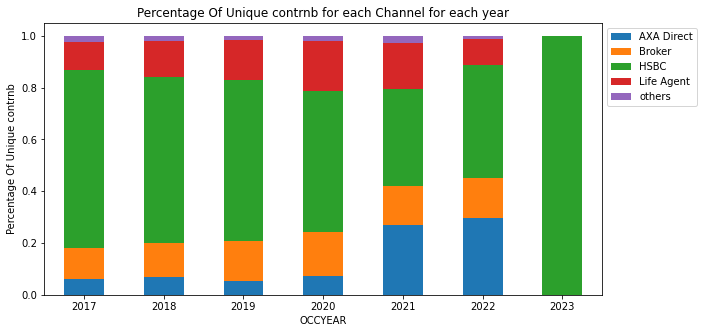

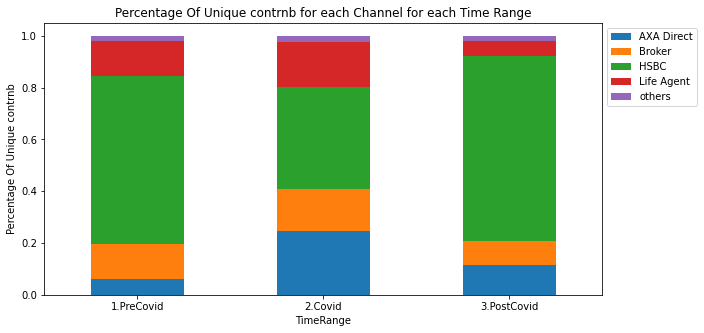

In [642]:
# plot a stacked column percentage chart of unique COWNNUM for each Channel for each year and show the number on the graph and scale to the same hight
F_usefull_PCC.groupby(['OCCYEAR','channel'])['contrnb'].nunique().unstack().apply(lambda x: x/x.sum(), axis=1).plot(kind='bar',stacked=True,figsize=(10,5),rot=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
#set y axis as Percentage Of Unique contrnb
plt.ylabel('Percentage Of Unique contrnb')
# add title
plt.title('Percentage Of Unique contrnb for each Channel for each year')
plt.show()

# plot a stacked column percentage chart of unique COWNNUM for each Channel for each year and show the number on the graph and scale to the same hight
F_usefull_PCC.groupby(['TimeRange','channel'])['contrnb'].nunique().unstack().apply(lambda x: x/x.sum(), axis=1).plot(kind='bar',stacked=True,figsize=(10,5),rot=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
#set y axis as Percentage Of Unique contrnb
plt.ylabel('Percentage Of Unique contrnb')
# add title
plt.title('Percentage Of Unique contrnb for each Channel for each Time Range')
plt.show()




In [643]:
# generate a df of unique contrnb for each Channel for each year
df =F_usefull_PCC.groupby(['OCCYEAR','channel'])['contrnb'].nunique().unstack()
df

channel,AXA Direct,Broker,HSBC,Life Agent,others
OCCYEAR,,,,,
2017,26058.0,53338.0,299675.0,48321.0,9967.0
2018,30045.0,57489.0,280591.0,60138.0,9053.0
2019,22291.0,65681.0,261442.0,64279.0,6568.0
2020,4875.0,11609.0,36993.0,13094.0,1302.0
2021,4317.0,2431.0,6026.0,2888.0,412.0
2022,7158.0,3701.0,10499.0,2486.0,256.0
2023,NaN,NaN,11.0,NaN,NaN


In [644]:
F_usefull_PCC

,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age_gp,gwp,nb_clm,ult_clm,paymnt_g,period,if_pol,nbrn,CLTSEX,modified_SECUITYNO,Single/Annual,OCCYEAR,CCYEAR,TimeRange
1214125,2134430,24830540,2017-01-02,2017-01-02,HSBC,TravelSurance (single trip),Single,Area 2,Self & Spouse,18.0,7. 15-30 Days,6. Age 61 - 70,127.95,0.0,0.0,0.0,2017-01-02,0.0,NB,M,E068903,NaN,2017,2017,1.PreCovid
1214126,2134430,24830540,2017-01-02,2017-01-02,HSBC,TravelSurance (single trip),Single,Area 2,Self & Spouse,0.0,7. 15-30 Days,6. Age 61 - 70,725.05,0.0,0.0,0.0,2017-01-02,0.0,NB,M,E068903,NaN,2017,2017,1.PreCovid
1223247,2095622,24835222,2017-01-06,2017-01-06,HSBC,TravelSurance (single trip),Single,Area 1,Self & Spouse,4.0,3. 4-5 Days,3. Age 31 - 40,32.55,0.0,0.0,0.0,2017-01-06,0.0,NB,M,Z059410,NaN,2017,2017,1.PreCovid
1223248,2095622,24835222,2017-01-06,2017-01-06,HSBC,TravelSurance (single trip),Single,Area 1,Self & Spouse,0.0,3. 4-5 Days,3. Age 31 - 40,184.45,0.0,0.0,0.0,2017-01-06,0.0,NB,M,Z059410,NaN,2017,2017,1.PreCovid
1226935,2079048,24837090,2017-01-08,2017-01-08,HSBC,TravelSurance (single trip),Single,Area 2,Self Only,9.0,5. 8-10 Days,4. Age 41 - 50,46.65,0.0,0.0,0.0,2017-01-08,0.0,NB,M,G475149,NaN,2017,2017,1.PreCovid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5086225,0784814,Z1942594,2022-10-26,2022-10-26,Broker,SmartTraveller Plus (Single),Single,Prestige,Insured Only,9.0,5. 8-10 Days,9. unknown,410.00,0.0,0.0,0.0,2022-10-26,1.0,NB,NaN,1434619,NaN,2022,2022,3.PostCovid
5086226,0516730,Z1942629,2022-10-25,2022-10-25,Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,6. Age 61 - 70,394.00,0.0,0.0,0.0,2022-10-25,1.0,NB,M,E478085,NaN,2022,2022,3.PostCovid
5086228,1046004,Z1942637,2022-11-04,2022-11-04,Broker,SmartTraveller (Single),Single,Specified Countries,Insured Only,8.0,5. 8-10 Days,6. Age 61 - 70,196.00,0.0,0.0,0.0,2022-11-04,0.0,NB,NaN,D241066,NaN,2022,2022,3.PostCovid
5086229,0361142,Z1942650,2022-10-25,2022-10-25,Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,4. Age 41 - 50,394.00,0.0,0.0,0.0,2022-10-25,1.0,NB,M,K957229,NaN,2022,2022,3.PostCovid


## Top 5(?) Product by Count/by WGP (weighted sum)

## Premium (GWP)

## Sum Insured

## Travel Duration

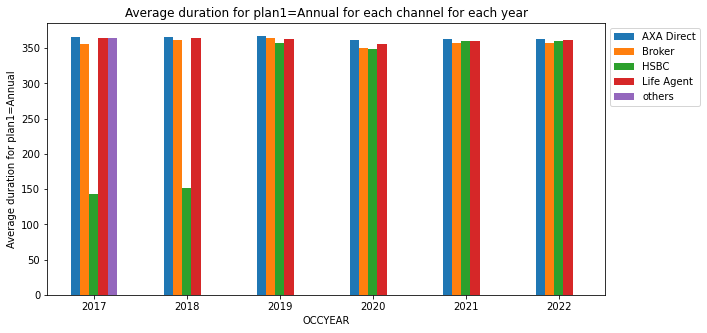

In [645]:
# for plan1=Annual, calculate the average duration for plan1 for each channel for each year then plot stacked graph add Y axis Label
F_usefull_PCC[F_usefull_PCC['plan1']=='Annual'].groupby(['OCCYEAR','channel'])['duration'].mean().sort_values(ascending=False).unstack().plot(kind='bar',figsize=(10,5),rot=0)
# y axis label 
plt.ylabel('Average duration for plan1=Annual')
# add title
plt.title('Average duration for plan1=Annual for each channel for each year')
# show legend
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()



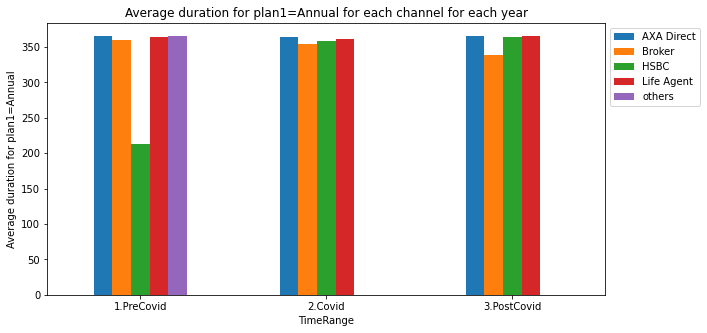

In [646]:
# for plan1=Annual, calculate the average duration for plan1 for each channel for each year then plot stacked graph add Y axis Label
F_usefull_PCC[F_usefull_PCC['plan1']=='Annual'].groupby(['TimeRange','channel'])['duration'].mean().sort_values(ascending=False).unstack().plot(kind='bar',figsize=(10,5),rot=0)
# y axis label 
plt.ylabel('Average duration for plan1=Annual')
# add title
plt.title('Average duration for plan1=Annual for each channel for each year')
# show legend
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [647]:
F_usefull_PCC['plan1'].unique()

array(['Single', 'Annual', nan], dtype=object)

Text(0.5, 1.0, 'Average duration for plan1=Single')

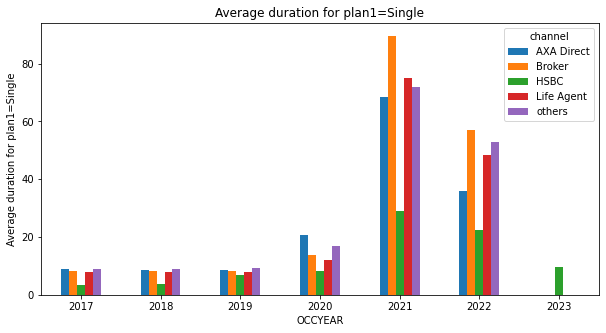

In [648]:
# for plan1=Single , calculate the average duration for plan1 for each channel for each year then plot stacked graph add Y axis Label
F_usefull_PCC[F_usefull_PCC['plan1']=='Single'].groupby(['OCCYEAR','channel'])['duration'].mean().sort_values(ascending=False).unstack().plot(kind='bar',figsize=(10,5),rot=0)
#  Y axis Label
plt.ylabel('Average duration for plan1=Single')
# add title
plt.title('Average duration for plan1=Single')


Text(0.5, 1.0, 'Average duration for plan1=Single')

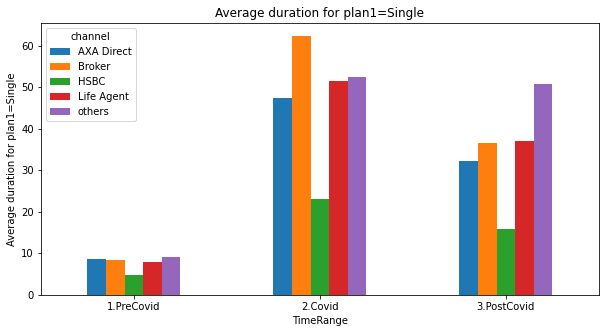

In [649]:
# for plan1=Single , calculate the average duration for plan1 for each channel for each year then plot stacked graph add Y axis Label
F_usefull_PCC[F_usefull_PCC['plan1']=='Single'].groupby(['TimeRange','channel'])['duration'].mean().sort_values(ascending=False).unstack().plot(kind='bar',figsize=(10,5),rot=0)
#  Y axis Label
plt.ylabel('Average duration for plan1=Single')
# add title
plt.title('Average duration for plan1=Single')


## Travel Frequency

## Inforce/Lapsed Count/Ratio of Annual Plan

## Age Range

In [650]:
F_usefull_PCC

,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age_gp,gwp,nb_clm,ult_clm,paymnt_g,period,if_pol,nbrn,CLTSEX,modified_SECUITYNO,Single/Annual,OCCYEAR,CCYEAR,TimeRange
1214125,2134430,24830540,2017-01-02,2017-01-02,HSBC,TravelSurance (single trip),Single,Area 2,Self & Spouse,18.0,7. 15-30 Days,6. Age 61 - 70,127.95,0.0,0.0,0.0,2017-01-02,0.0,NB,M,E068903,NaN,2017,2017,1.PreCovid
1214126,2134430,24830540,2017-01-02,2017-01-02,HSBC,TravelSurance (single trip),Single,Area 2,Self & Spouse,0.0,7. 15-30 Days,6. Age 61 - 70,725.05,0.0,0.0,0.0,2017-01-02,0.0,NB,M,E068903,NaN,2017,2017,1.PreCovid
1223247,2095622,24835222,2017-01-06,2017-01-06,HSBC,TravelSurance (single trip),Single,Area 1,Self & Spouse,4.0,3. 4-5 Days,3. Age 31 - 40,32.55,0.0,0.0,0.0,2017-01-06,0.0,NB,M,Z059410,NaN,2017,2017,1.PreCovid
1223248,2095622,24835222,2017-01-06,2017-01-06,HSBC,TravelSurance (single trip),Single,Area 1,Self & Spouse,0.0,3. 4-5 Days,3. Age 31 - 40,184.45,0.0,0.0,0.0,2017-01-06,0.0,NB,M,Z059410,NaN,2017,2017,1.PreCovid
1226935,2079048,24837090,2017-01-08,2017-01-08,HSBC,TravelSurance (single trip),Single,Area 2,Self Only,9.0,5. 8-10 Days,4. Age 41 - 50,46.65,0.0,0.0,0.0,2017-01-08,0.0,NB,M,G475149,NaN,2017,2017,1.PreCovid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5086225,0784814,Z1942594,2022-10-26,2022-10-26,Broker,SmartTraveller Plus (Single),Single,Prestige,Insured Only,9.0,5. 8-10 Days,9. unknown,410.00,0.0,0.0,0.0,2022-10-26,1.0,NB,NaN,1434619,NaN,2022,2022,3.PostCovid
5086226,0516730,Z1942629,2022-10-25,2022-10-25,Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,6. Age 61 - 70,394.00,0.0,0.0,0.0,2022-10-25,1.0,NB,M,E478085,NaN,2022,2022,3.PostCovid
5086228,1046004,Z1942637,2022-11-04,2022-11-04,Broker,SmartTraveller (Single),Single,Specified Countries,Insured Only,8.0,5. 8-10 Days,6. Age 61 - 70,196.00,0.0,0.0,0.0,2022-11-04,0.0,NB,NaN,D241066,NaN,2022,2022,3.PostCovid
5086229,0361142,Z1942650,2022-10-25,2022-10-25,Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,4. Age 41 - 50,394.00,0.0,0.0,0.0,2022-10-25,1.0,NB,M,K957229,NaN,2022,2022,3.PostCovid


In [651]:
# sample=F_usefull_PCC[['modified_SECUITYNO','age','OCCDATE','contrnb']]
sample =F_usefull_PCC

In [652]:
F_usefull_PCC[F_usefull_PCC['modified_SECUITYNO']=='C75700360']

,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age_gp,gwp,nb_clm,ult_clm,paymnt_g,period,if_pol,nbrn,CLTSEX,modified_SECUITYNO,Single/Annual,OCCYEAR,CCYEAR,TimeRange
2541715,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,365.0,Annual,2. Age 17 - 30,583.8,0.0,0.0,0.0,2018-04-10,0.0,NB,M,C75700360,Annual,2018,2018,1.PreCovid
2541716,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,NaN,Annual,2. Age 17 - 30,0.0,0.0,0.0,0.0,2018-04-10,1.0,NB,M,C75700360,Annual,2018,2018,1.PreCovid
2541717,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,2. Age 17 - 30,1608.2,0.0,0.0,0.0,2018-04-10,0.0,NB,M,C75700360,Annual,2018,2018,1.PreCovid
2541718,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,2. Age 17 - 30,0.0,0.0,0.0,0.0,2018-04-10,0.0,NB,M,C75700360,Annual,2018,2018,1.PreCovid
3460202,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,365.0,Annual,2. Age 17 - 30,0.0,0.0,0.0,0.0,2018-04-10,0.0,NB,M,C75700360,Annual,2018,2018,1.PreCovid
3460203,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,NaN,Annual,2. Age 17 - 30,0.0,0.0,0.0,0.0,2018-04-10,0.0,NB,M,C75700360,Annual,2018,2018,1.PreCovid
3460204,2648145,24337169,2018-04-10,2019-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,NaN,Annual,2. Age 17 - 30,0.0,0.0,0.0,0.0,2019-04-10,0.0,RN,M,C75700360,Annual,2018,2019,1.PreCovid
3460205,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,2. Age 17 - 30,0.0,0.0,0.0,0.0,2018-04-10,0.0,NB,M,C75700360,Annual,2018,2018,1.PreCovid
3460206,2648145,24337169,2018-04-10,2018-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,2. Age 17 - 30,0.0,0.0,0.0,0.0,2018-04-10,0.0,NB,M,C75700360,Annual,2018,2018,1.PreCovid
3460207,2648145,24337169,2018-04-10,2019-04-10,HSBC,MultiTrip TravelSurance (Annual),Annual,Area 2,Self Only,0.0,Annual,2. Age 17 - 30,0.0,0.0,0.0,0.0,2019-04-10,0.0,RN,M,C75700360,Annual,2018,2019,1.PreCovid


In [653]:
# sample.loc[sample.groupby(['modified_SECUITYNO','contrnb'])['age'].idxmin()][sample['modified_SECUITYNO']=='C75700360']

In [654]:
# uniqueAgeForEachCustomerAndEachPolicyNo=sample.loc[sample.groupby(['modified_SECUITYNO','contrnb'])['age'].idxmin()]

In [655]:
#drop the rows where age is 9999 or 100 or 0 or 1 
# uniqueAgeForEachCustomerAndEachPolicyNo=uniqueAgeForEachCustomerAndEachPolicyNo[~uniqueAgeForEachCustomerAndEachPolicyNo['age'].isin([9999,100,0,1])]
# #divide the age into different age group, for example age at 46 belongs to the age group 46-50, age at 42 belongs to the age group 40-45, value count of each age group then plot graph to show the distribution of age group using seaborn
# uniqueAgeForEachCustomerAndEachPolicyNo['age_GAP']=pd.cut(uniqueAgeForEachCustomerAndEachPolicyNo['age'],bins=[0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100],labels=['0-5','5-10','10-15','15-20','20-25','25-30','30-35','35-40','40-45','45-50','50-55','55-60','60-65','65-70','70-75','75-80','80-85','85-90','90-95','95-100'])
# uniqueAgeForEachCustomerAndEachPolicyNo['age_GAP'].value_counts().plot(kind="bar")


In [656]:
# uniqueAgeForEachCustomerAndEachPolicyNo

In [657]:
# # plot graph using seaborn to show the value count of age_gp 
# plt.figure(figsize=(50,10))
# df=uniqueAgeForEachCustomerAndEachPolicyNo
# sns.countplot(x='age',data =df)
# plt.title('Distribution of Age')
# plt.show()

In [658]:
# # plot graph using seaborn to show the value count of age_gp 
# plt.figure(figsize=(20,10))
# df=uniqueAgeForEachCustomerAndEachPolicyNo
# sns.countplot(x='age_GAP',data =df)
# plt.title('Distribution of Age Group')
# plt.show()


In [659]:
# # get the value count of each age group for each channel for each year then generate a pivot table
# uniqueAgeForEachCustomerAndEachPolicyNo.groupby(['OCCYEAR','channel','age_GAP'])['age_GAP'].count().unstack().fillna(0)

In [660]:
# get the value count of each age group for each channel for each year then generate a heat map
# import seaborn as sns
# import matplotlib.pyplot as plt
# plt.figure(figsize=(20,10))
# sns.heatmap(uniqueAgeForEachCustomerAndEachPolicyNo.groupby(['OCCYEAR','channel','age_gp'])['age_gp'].count().unstack().fillna(0),annot=True,fmt='d',cmap='YlGnBu')
# plt.title('Distribution of Age Group for each channel for each year')
# plt.show()


In [661]:
# #find the age_gp(and the number) with the most number for each channel for each year then generate a table

# uniqueAgeForEachCustomerAndEachPolicyNo.groupby(['OCCYEAR','channel'])['age_GAP'].agg(lambda x:x.value_counts().index[0]).sort_values(ascending=False).unstack()

In [662]:
#find the age_gp(and the number) with the most number for each channel for each year then generate a table

F_usefull_PCC.groupby(['OCCYEAR','channel'])['age_gp'].agg(lambda x:x.value_counts().index[0]).sort_values(ascending=False).unstack()

channel,AXA Direct,Broker,HSBC,Life Agent,others
OCCYEAR,,,,,
2017,2. Age 17 - 30,4. Age 41 - 50,3. Age 31 - 40,2. Age 17 - 30,9. unknown
2018,2. Age 17 - 30,4. Age 41 - 50,3. Age 31 - 40,2. Age 17 - 30,9. unknown
2019,2. Age 17 - 30,4. Age 41 - 50,3. Age 31 - 40,2. Age 17 - 30,9. unknown
2020,2. Age 17 - 30,4. Age 41 - 50,4. Age 41 - 50,2. Age 17 - 30,9. unknown
2021,9. unknown,9. unknown,5. Age 51 - 60,9. unknown,9. unknown
2022,2. Age 17 - 30,4. Age 41 - 50,5. Age 51 - 60,9. unknown,5. Age 51 - 60
2023,NaN,NaN,5. Age 51 - 60,NaN,NaN


Text(0.5, 1.0, 'Number of unique client for each age group for each year')

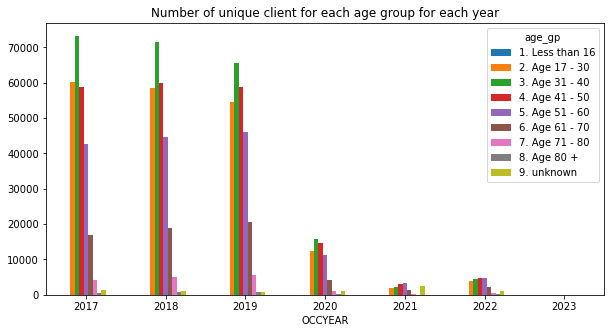

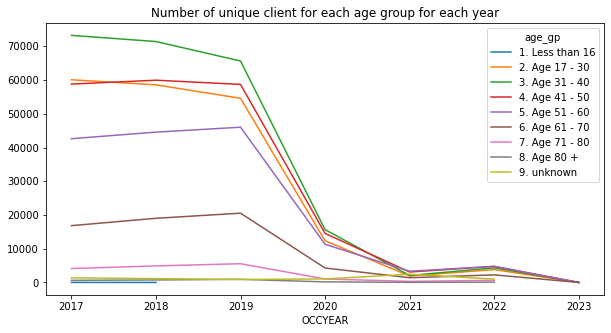

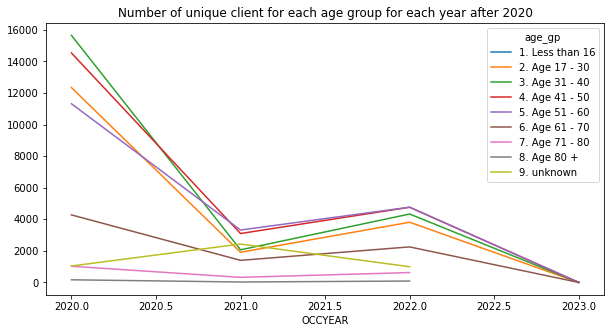

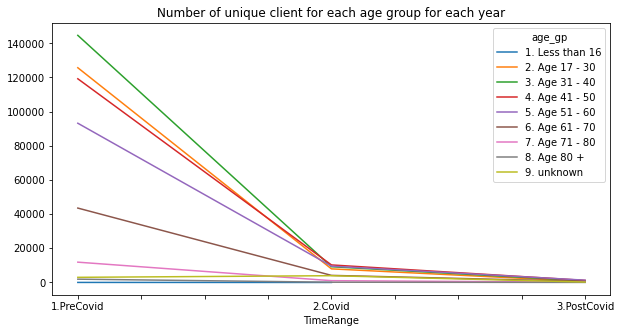

In [663]:
# for each age_gp, find the unique client number for each year then generate a graph
F_usefull_PCC.groupby(['OCCYEAR','age_gp'])['modified_SECUITYNO'].nunique().unstack().plot(kind='bar',figsize=(10,5),rot=0)
# add title
plt.title('Number of unique client for each age group for each year')

# for each age_gp, find the unique client number for each year then generate a graph
F_usefull_PCC.groupby(['OCCYEAR','age_gp'])['modified_SECUITYNO'].nunique().unstack().plot(kind='line',figsize=(10,5),rot=0)
# add title
plt.title('Number of unique client for each age group for each year')

# for each age_gp, find the unique client number for each year after 2020 then generate a line graph
F_usefull_PCC[F_usefull_PCC['OCCYEAR']>=2020].groupby(['OCCYEAR','age_gp'])['modified_SECUITYNO'].nunique().unstack().plot(kind='line',figsize=(10,5),rot=0)
# add title
plt.title('Number of unique client for each age group for each year after 2020')


# for each age_gp, find the unique client number for each year then generate a graph
F_usefull_PCC.groupby(['TimeRange','age_gp'])['modified_SECUITYNO'].nunique().unstack().plot(kind='line',figsize=(10,5),rot=0)
# add title
plt.title('Number of unique client for each age group for each year')

In [664]:
# # calculate average age for each channel for each year then plot graph
# F_usefull_PCC.groupby(['OCCYEAR','channel'])['age'].mean().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(15,5),rot=0)
# # add title 
# plt.title('Average age for each channel for each year')
# plt.ylabel('Average age')

# # calculate average age for each channel for each year then plot graph
# F_usefull_PCC.groupby(['TimeRange','channel'])['age'].mean().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(15,5),rot=0)
# # add title
# plt.title('Average age for each channel for each TimeRange')
# plt.ylabel('Average age')



## Gender

In [665]:
F_usefull_PCC

,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age_gp,gwp,nb_clm,ult_clm,paymnt_g,period,if_pol,nbrn,CLTSEX,modified_SECUITYNO,Single/Annual,OCCYEAR,CCYEAR,TimeRange
1214125,2134430,24830540,2017-01-02,2017-01-02,HSBC,TravelSurance (single trip),Single,Area 2,Self & Spouse,18.0,7. 15-30 Days,6. Age 61 - 70,127.95,0.0,0.0,0.0,2017-01-02,0.0,NB,M,E068903,NaN,2017,2017,1.PreCovid
1214126,2134430,24830540,2017-01-02,2017-01-02,HSBC,TravelSurance (single trip),Single,Area 2,Self & Spouse,0.0,7. 15-30 Days,6. Age 61 - 70,725.05,0.0,0.0,0.0,2017-01-02,0.0,NB,M,E068903,NaN,2017,2017,1.PreCovid
1223247,2095622,24835222,2017-01-06,2017-01-06,HSBC,TravelSurance (single trip),Single,Area 1,Self & Spouse,4.0,3. 4-5 Days,3. Age 31 - 40,32.55,0.0,0.0,0.0,2017-01-06,0.0,NB,M,Z059410,NaN,2017,2017,1.PreCovid
1223248,2095622,24835222,2017-01-06,2017-01-06,HSBC,TravelSurance (single trip),Single,Area 1,Self & Spouse,0.0,3. 4-5 Days,3. Age 31 - 40,184.45,0.0,0.0,0.0,2017-01-06,0.0,NB,M,Z059410,NaN,2017,2017,1.PreCovid
1226935,2079048,24837090,2017-01-08,2017-01-08,HSBC,TravelSurance (single trip),Single,Area 2,Self Only,9.0,5. 8-10 Days,4. Age 41 - 50,46.65,0.0,0.0,0.0,2017-01-08,0.0,NB,M,G475149,NaN,2017,2017,1.PreCovid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5086225,0784814,Z1942594,2022-10-26,2022-10-26,Broker,SmartTraveller Plus (Single),Single,Prestige,Insured Only,9.0,5. 8-10 Days,9. unknown,410.00,0.0,0.0,0.0,2022-10-26,1.0,NB,NaN,1434619,NaN,2022,2022,3.PostCovid
5086226,0516730,Z1942629,2022-10-25,2022-10-25,Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,6. Age 61 - 70,394.00,0.0,0.0,0.0,2022-10-25,1.0,NB,M,E478085,NaN,2022,2022,3.PostCovid
5086228,1046004,Z1942637,2022-11-04,2022-11-04,Broker,SmartTraveller (Single),Single,Specified Countries,Insured Only,8.0,5. 8-10 Days,6. Age 61 - 70,196.00,0.0,0.0,0.0,2022-11-04,0.0,NB,NaN,D241066,NaN,2022,2022,3.PostCovid
5086229,0361142,Z1942650,2022-10-25,2022-10-25,Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,4. Age 41 - 50,394.00,0.0,0.0,0.0,2022-10-25,1.0,NB,M,K957229,NaN,2022,2022,3.PostCovid


Text(0.5, 1.0, 'Number of unique clients for CLTSEX=F')

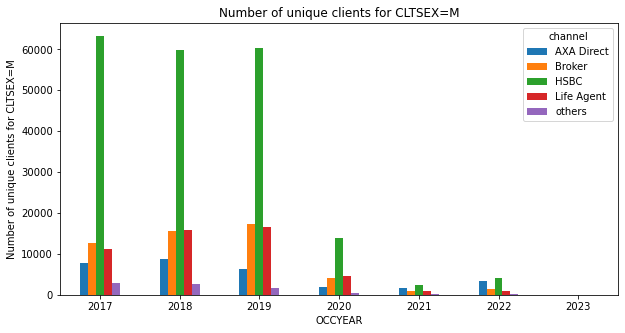

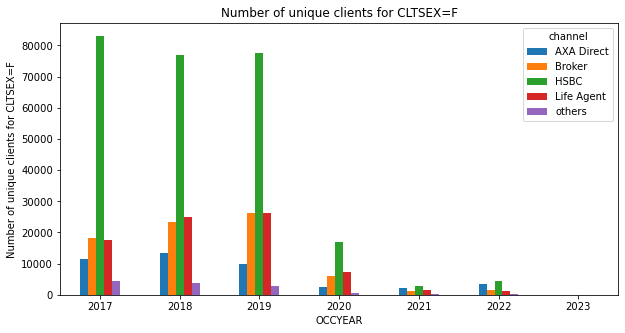

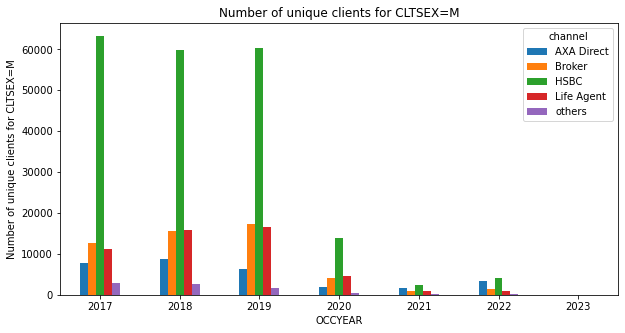

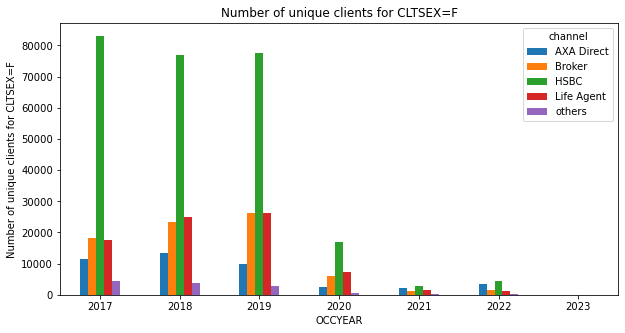

In [666]:
# count CLTSEX for each channel for each year then plot with axis labels and title using seaborn and matplotlib
# import sns




# for CLTSEX=M , calculate the unique clients for each channel for each year then plot graph add Y axis Label and title
F_usefull_PCC[F_usefull_PCC['CLTSEX']=='M'].groupby(['OCCYEAR','channel'])['modified_SECUITYNO'].nunique().sort_values(ascending=False).unstack().plot(kind='bar',figsize=(10,5),rot=0)
#  Y axis Label
plt.ylabel('Number of unique clients for CLTSEX=M')
# add title
plt.title('Number of unique clients for CLTSEX=M')


# for CLTSEX=F , calculate the unique clients for each channel for each year then plot graph add Y axis Label and title
F_usefull_PCC[F_usefull_PCC['CLTSEX']=='F'].groupby(['OCCYEAR','channel'])['modified_SECUITYNO'].nunique().sort_values(ascending=False).unstack().plot(kind='bar',figsize=(10,5),rot=0)
#  Y axis Label
plt.ylabel('Number of unique clients for CLTSEX=F')
# add title
plt.title('Number of unique clients for CLTSEX=F')


# for CLTSEX=M , calculate the unique clients for each channel for each year then plot graph add Y axis Label and title
F_usefull_PCC[F_usefull_PCC['CLTSEX']=='M'].groupby(['OCCYEAR','channel'])['modified_SECUITYNO'].nunique().sort_values(ascending=False).unstack().plot(kind='bar',figsize=(10,5),rot=0)
#  Y axis Label
plt.ylabel('Number of unique clients for CLTSEX=M')
# add title
plt.title('Number of unique clients for CLTSEX=M')


# for CLTSEX=F , calculate the unique clients for each channel for each year then plot graph add Y axis Label and title
F_usefull_PCC[F_usefull_PCC['CLTSEX']=='F'].groupby(['OCCYEAR','channel'])['modified_SECUITYNO'].nunique().sort_values(ascending=False).unstack().plot(kind='bar',figsize=(10,5),rot=0)
#  Y axis Label
plt.ylabel('Number of unique clients for CLTSEX=F')
# add title
plt.title('Number of unique clients for CLTSEX=F')



Text(0.5, 1.0, 'Number of unique clients for each channel for each CLTSEX')

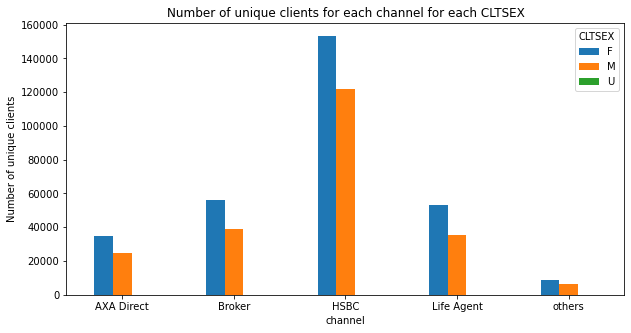

In [667]:
# calculate the unique clients for each channel for each CLTSEX then plot graph add Y axis Label and title
F_usefull_PCC.groupby(['channel','CLTSEX'])['modified_SECUITYNO'].nunique().sort_values(ascending=False).unstack().plot(kind='bar',figsize=(10,5),rot=0)
#  Y axis Label
plt.ylabel('Number of unique clients')
# add title
plt.title('Number of unique clients for each channel for each CLTSEX')


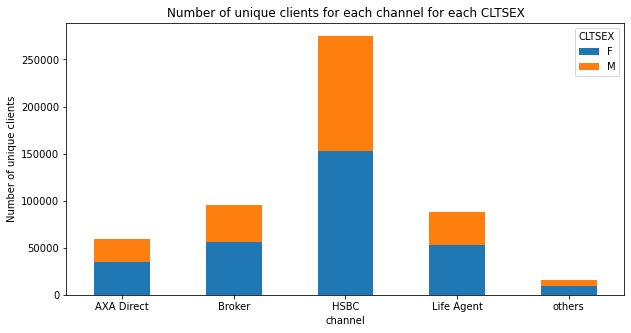

In [668]:
# calculate the unique clients for each channel for each CLTSEX then plot stacked graph add Y axis Label and title 
F_usefull_PCC.groupby(['channel','CLTSEX'])['modified_SECUITYNO'].nunique().sort_values(ascending=False).unstack().plot(kind='bar',stacked=True,figsize=(10,5),rot=0)
#  Y axis Label
plt.ylabel('Number of unique clients')
# add title
plt.title('Number of unique clients for each channel for each CLTSEX')
# also show the percentage of each CLTSEX for each channel
plt.legend(title='CLTSEX',loc='upper right',labels=['F','M'])



Text(0.5, 1.0, 'Number of unique clients for each plan1 for each CLTSEX')

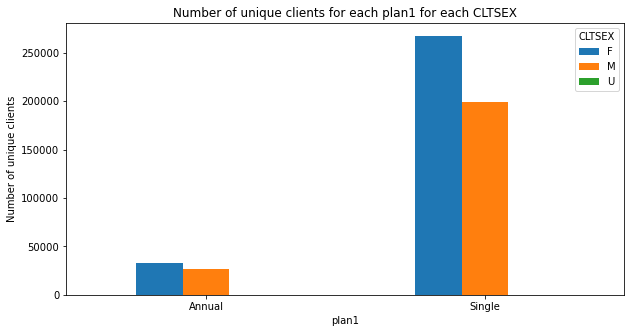

In [669]:
# calculate the unique clients for each plan1 for each CLTSEX then plot stacked graph add Y axis Label and title 
F_usefull_PCC.groupby(['plan1','CLTSEX'])['modified_SECUITYNO'].nunique().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
#  Y axis Label
plt.ylabel('Number of unique clients')
# add title
plt.title('Number of unique clients for each plan1 for each CLTSEX')
# also show the percentage of each CLTSEX for each channel


Text(0.5, 1.0, 'Number of unique clients for each year for each CLTSEX')

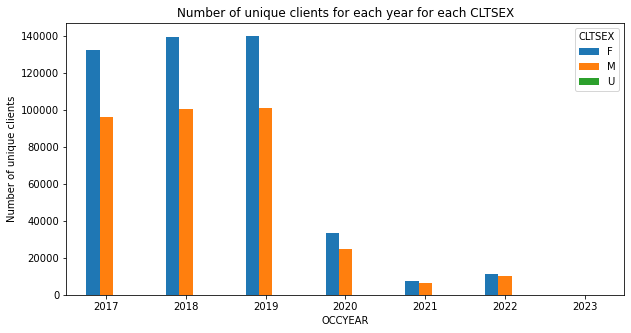

In [670]:
# calculate the unique clients for each year for each CLTSEX then plot  graph add Y axis Label and title 
F_usefull_PCC.groupby(['OCCYEAR','CLTSEX'])['modified_SECUITYNO'].nunique().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
#  Y axis Label
plt.ylabel('Number of unique clients')
# add title
plt.title('Number of unique clients for each year for each CLTSEX')
# also show the percentage of each CLTSEX for each channel


Text(0.5, 1.0, 'Number of unique clients for each year for each CLTSEX')

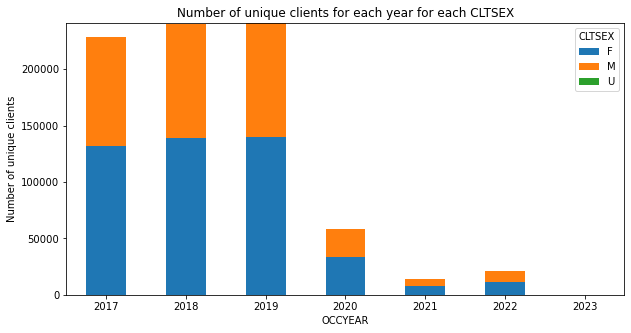

In [671]:
# calculate the unique clients and the percentage for each year for each CLTSEX then plot  graph add Y axis Label and title 
F_usefull_PCC.groupby(['OCCYEAR','CLTSEX'])['modified_SECUITYNO'].nunique().sort_values(ascending=False).unstack().plot(kind='bar',stacked=True,figsize=(10,5),rot=0)
#  Y axis Label
plt.ylabel('Number of unique clients')
# add title
plt.title('Number of unique clients for each year for each CLTSEX')
# also show the percentage of each CLTSEX for each channel


## Inforce/Lapsed Count/Ratio of Annual Plan

In [672]:
#generate a new column called 'Inforce/Lapsed' to show if the client is inforce or lapsed, using period and if_pol to identify whether the policy is inforce in that year, e.g. if_pol=1 and period=2022 means that the policy is inforce in the year 2022
# F_usefull_PCC['Inforce/Lapsed'] = np.where((F_usefull_PCC['if_pol']==1) & (F_usefull_PCC['period']==F_usefull_PCC['OCCYEAR']), 'Inforce', 'Lapsed')

In [673]:
# convert period to datetime using the previous formats
F_usefull_PCC['period'] = pd.to_datetime(F_usefull_PCC['period'], format='%Y%m%d')

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_23712/866665257.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  F_usefull_PCC['period'] = pd.to_datetime(F_usefull_PCC['period'], format='%Y%m%d')


In [674]:
# generate a new col called "period_year" to show the year of the period
F_usefull_PCC['period_year'] = F_usefull_PCC['period'].dt.year

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_23712/3944806073.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  F_usefull_PCC['period_year'] = F_usefull_PCC['period'].dt.year


Text(0.5, 1.0, 'Number of unique policies for plan1=Annual for each year')

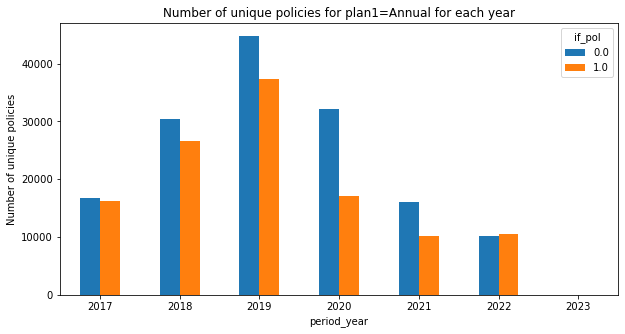

In [675]:
# for plan1=Annual, calculate the inforce and Lapsed  count for each year then plot  graph add Y axis Label and title
F_usefull_PCC[F_usefull_PCC['plan1']=='Annual'].groupby(['period_year','if_pol'])['contrnb'].nunique().sort_values(ascending=False).unstack().plot(kind='bar',stacked=False,figsize=(10,5),rot=0)
#  Y axis Label
plt.ylabel('Number of unique policies')
# add title
plt.title('Number of unique policies for plan1=Annual for each year')

In [676]:
# for plan1=Annual, calculate the inforce and Lapsed  ratio for each year then normalize and generate a table
F_usefull_PCC[F_usefull_PCC['plan1']=='Annual'].groupby(['period_year','if_pol'])['contrnb'].nunique().sort_values(ascending=False).unstack().apply(lambda x: x/x.sum(), axis=1)

if_pol,0.0,1.0
period_year,,
2017,0.508392,0.491608
2018,0.534589,0.465411
2019,0.544855,0.455145
2020,0.651600,0.348400
2021,0.612410,0.387590
2022,0.492120,0.507880
2023,1.000000,NaN


In [677]:
# for plan1=Annual, calculate the inforce and Lapsed  count for each year then normalize and generate a table
F_usefull_PCC[F_usefull_PCC['plan1']=='Annual'].groupby(['period_year','if_pol'])['contrnb'].nunique().sort_values(ascending=False).unstack()

if_pol,0.0,1.0
period_year,,
2017,16751.0,16198.0
2018,30501.0,26554.0
2019,44762.0,37392.0
2020,32062.0,17143.0
2021,16009.0,10132.0
2022,10149.0,10474.0
2023,21.0,NaN


In [678]:
10474/(10474+10149)

0.5078795519565533

# Import  LH


In [679]:
#### import L&H app data
health_app_df = pd.read_parquet(os.path.join(VER_1122_DIR, "HEALTH_APPLICATION_19970101.parquet"))
health_app_his_df = pd.read_parquet(os.path.join(VER_1122_DIR, "HEALTH_APPLICATION_HISTORIC_19970101.parquet"))
life_app_df = pd.read_parquet(os.path.join(VER_1122_DIR, "LIFE_APPLICATION_19970101.parquet"))
life_app_his_df = pd.read_parquet(os.path.join(VER_1122_DIR, "LIFE_APPLICATION_HISTORIC_19970101.parquet"))
dis_app_df = pd.read_parquet(os.path.join(VER_1122_DIR, "DISABLE_APPLICATION_19970101.parquet"))
dis_app_his_df = pd.read_parquet(os.path.join(VER_1122_DIR, "DISABLE_APPLICATION_HISTORIC_19970101.parquet"))

In [680]:
all_app_wo_rider_df = pd.concat([health_app_df, health_app_his_df, life_app_df, life_app_his_df, dis_app_df, dis_app_his_df], axis=0)

print("all_app_wo_rider_df size before drop duplicates:", all_app_wo_rider_df.shape)
# check the number of duplicated POLICY_NO at all_app_wo_rider_df
print("number of duplicated PNO:", all_app_wo_rider_df["POLICY_NO"].duplicated().sum())

# drop duplicates of POLICY_NO at all_app_wo_rider_df
all_app_wo_rider_df.drop_duplicates("POLICY_NO", inplace=True)
print("all_app_wo_rider_df size after drop duplicates:", all_app_wo_rider_df.shape)
# convert SUBMIT_DATE to datetime
all_app_wo_rider_df["SUBMIT_DATE"] = pd.to_datetime(all_app_wo_rider_df["SUBMIT_DATE"], format="%Y%m%d")

print("before filter by 2002-01-01:", all_app_wo_rider_df.shape)

# keep all_app_wo_rider_df with "SUBMIT_DATE" >= "20020101"
all_app_wo_rider_df = all_app_wo_rider_df[all_app_wo_rider_df["SUBMIT_DATE"] >= pd.to_datetime(20020101, format="%Y%m%d")]

print("after filter by 2002-01-01:", all_app_wo_rider_df.shape)

all_app_wo_rider_df size before drop duplicates: (2454138, 85)
number of duplicated PNO: 8
all_app_wo_rider_df size after drop duplicates: (2454130, 85)
before filter by 2002-01-01: (2454130, 85)
after filter by 2002-01-01: (1921779, 85)


In [681]:
print(list(all_app_wo_rider_df.columns))

['APPROVAL_DATE_FIRST', 'APPROVAL_DATE_LAST', 'POLICY_NO', 'SUBMIT_DATE', 'ISSUE_DATE', 'LAST_UW_DATE', 'FOLLOWUP_DATE', 'UW_REMARKS_1', 'UW_REMARKS_2', 'UW_REMARKS_3', 'APP_STATUS_CODE', 'UN_CODE', 'SUBSTDECLINE_OPTION', 'POLICY_DATE', 'EXPIRY_DATE', 'MEDICAL_CODE', 'LANGUAGE_FLAG', 'PAYMENT_MODE', 'PAYMENT_METHOD', 'LOCATION_OF_POLICY', 'MONTHS_DEBITED', 'POLICY_FACTOR', 'CURRENCY', 'TOTAL_LOADING', 'ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR', 'MODAL_PREM_EXCLUDE_TOPUP_REGULAR', 'AGENT_1_CODE', 'AGENT_2_CODE', 'INSURED_NAME', 'SEX', 'AGE_AT_ISSUE', 'BIRTH_DATE', 'ID_NO', 'MARITAL_STATUS', 'INCOME_LEVEL', 'CORR_ADDRESS1', 'CORR_ADDRESS2', 'CORR_ADDRESS3', 'CORR_ADDRESS4', 'CORR_CITY_CODE', 'OWNER', 'OWNER_HKID', 'OWNER_GENDER', 'INSURED_PREV_POLICY_NO1', 'INSURED_PREV_POLICY_NO2', 'INSURED_PREV_POLICY_NO3', 'INSURED_PREV_POLICY_NO4', 'INSURED_PREV_POLICY_NO5', 'INSURED_PREV_POLICY_NO6', 'INSURED_PREV_POLICY_NO7', 'INSURED_PREV_POLICY_NO8', 'INSURED_PREV_POLICY_NO9', 'INSURED_PREV_POLICY_NO10'

In [682]:
# change SUBMIT_DATE and POLICY_DATE to datetime format 
all_app_wo_rider_df["SUBMIT_DATE"] = pd.to_datetime(all_app_wo_rider_df["SUBMIT_DATE"], format="%Y%m%d")
all_app_wo_rider_df["POLICY_DATE"] = pd.to_datetime(all_app_wo_rider_df["POLICY_DATE"], format="%Y%m%d")
# strip all the space in OWNER_HKID and ID_NO
all_app_wo_rider_df["OWNER_HKID"] = all_app_wo_rider_df["OWNER_HKID"].str.strip()
# strip to avoid space in id columns
# all_app_w_rider_df["OWNER_HKID"] = all_app_w_rider_df["OWNER_HKID"].str.strip()

all_app_wo_rider_df["ID_NO"] = all_app_wo_rider_df["ID_NO"].str.strip()


In [683]:
# assign a new column id, use OWNER_HKID if not equals to "", otherwise use ID_NO
all_app_wo_rider_df["owner_id"] = np.where(all_app_wo_rider_df["OWNER_HKID"]!="", all_app_wo_rider_df["OWNER_HKID"], all_app_wo_rider_df["ID_NO"])
(all_app_wo_rider_df["owner_id"] == "").sum()

8364

In [684]:
all_app_wo_rider_df["modified_owner_id"] = all_app_wo_rider_df["owner_id"].str.replace(r'\W+', '')

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_23712/1021358819.py:1: FutureWarning: The default value of regex will change from True to False in a future version.
  all_app_wo_rider_df["modified_owner_id"] = all_app_wo_rider_df["owner_id"].str.replace(r'\W+', '')


In [685]:
# extract base plan type from plan code
import sys,os
sys.path.append(os.getcwd())
# from src.src_test2 import Test2

from common import PLAN_TYPE_LST, WGP_LST, INFORCE_STATUS_LST, TRAVEL_SINGLE_MULTI_TRIP_DICT
from helper_function import find_plan_type, one_hot

all_app_wo_rider_df["BASE_PLAN_TYPE"] = find_plan_type(all_app_wo_rider_df["PLAN_CODE"])
all_app_wo_rider_df["BASE_PLAN_TYPE"].value_counts()

traditional_life    677941
critical_illness    421319
medical             397518
unit_link           247878
term                116721
old_exmlc            57172
unknown               3055
long_term_care         151
disability              24
Name: BASE_PLAN_TYPE, dtype: int64

In [686]:
useful_LH=all_app_wo_rider_df[['POLICY_NO','SUBMIT_DATE','POLICY_DATE','modified_owner_id','PLAN_CODE','BASE_PLAN_TYPE','SEX','AGE_AT_ISSUE','BIRTH_DATE','MARITAL_STATUS','INCOME_LEVEL','LIFE_SUM_INSURED','CLASS_CODE','ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR','CURRENCY']]

In [687]:
# show ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR and CURRENCY
useful_LH[['ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR','CURRENCY']].head()

,ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR,CURRENCY
0,17004.0,HKD
1,3403.0,HKD
2,14568.0,HKD
3,7430.0,HKD
4,16264.0,HKD


In [688]:
# change SUBMIT_DATE and POLICY_DATE to datetime format 
useful_LH["SUBMIT_DATE"] = pd.to_datetime(useful_LH["SUBMIT_DATE"], format="%Y%m%d")
useful_LH["POLICY_DATE"] = pd.to_datetime(useful_LH["POLICY_DATE"], format="%Y%m%d")


C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_23712/153079825.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useful_LH["SUBMIT_DATE"] = pd.to_datetime(useful_LH["SUBMIT_DATE"], format="%Y%m%d")
C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_23712/153079825.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  useful_LH["POLICY_DATE"] = pd.to_datetime(useful_LH["POLICY_DATE"], format="%Y%m%d")


In [689]:
# #print shape of useful_LH
# print(useful_LH.shape)
# # drop ID_NO if it's NaN
# useful_LH = useful_LH[useful_LH["ID_NO"].notna()]
# #print shape of useful_LH
# print(useful_LH.shape)

In [690]:
useful_LH['modified_owner_id']

0       E393791
1       Z134742
2       K898720
3       K880895
4       E406942
         ...   
5453    Y343203
5454    C615117
5455    M348055
5456    Z947224
5457    Z960321
Name: modified_owner_id, Length: 1921779, dtype: object

# merge with LH

In [691]:
F_usefull_PCC['modified_SECUITYNO']

1214125    E068903
1214126    E068903
1223247    Z059410
1223248    Z059410
1226935    G475149
            ...   
5086225    1434619
5086226    E478085
5086228    D241066
5086229    K957229
5086230    1434619
Name: modified_SECUITYNO, Length: 2923210, dtype: object

In [692]:
# how many unique modified_owner_id in useful_LH is in F_usefull_PCC['modified_SECUITYNO']
print("how many unique modified_owner_id in useful_LH is in F_usefull_PCC['modified_SECUITYNO']:", len(set(useful_LH['modified_owner_id']) & set(F_usefull_PCC['modified_SECUITYNO'])))

how many unique modified_owner_id in useful_LH is in F_usefull_PCC['modified_SECUITYNO']: 88232


In [693]:
print(F_usefull_PCC.shape)

# left merge pa_occ_df with all_app_w_rider_non_na_id_medical_df, left_on="modified_SECUITYNO", right_on="modified_owner_id"
Base_LH_df = pd.merge(F_usefull_PCC, useful_LH, how="left", left_on="modified_SECUITYNO", right_on="modified_owner_id")

print(Base_LH_df.shape)

(2923210, 26)
(4239306, 41)


In [694]:
Base_LH_df.tail(3)

,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age_gp,gwp,nb_clm,ult_clm,paymnt_g,period,if_pol,nbrn,CLTSEX,modified_SECUITYNO,Single/Annual,OCCYEAR,CCYEAR,TimeRange,period_year,POLICY_NO,SUBMIT_DATE,POLICY_DATE,modified_owner_id,PLAN_CODE,BASE_PLAN_TYPE,SEX,AGE_AT_ISSUE,BIRTH_DATE,MARITAL_STATUS,INCOME_LEVEL,LIFE_SUM_INSURED,CLASS_CODE,ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR,CURRENCY
4239303,1046004,Z1942637,2022-11-04,2022-11-04,Broker,SmartTraveller (Single),Single,Specified Countries,Insured Only,8.0,5. 8-10 Days,6. Age 61 - 70,196.0,0.0,0.0,0.0,2022-11-04,0.0,NB,NaN,D241066,NaN,2022,2022,3.PostCovid,2022,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4239304,0361142,Z1942650,2022-10-25,2022-10-25,Broker,SmartTraveller Plus (Single),Single,Advance,Insured Only,12.0,6. 11-14 Days,4. Age 41 - 50,394.0,0.0,0.0,0.0,2022-10-25,1.0,NB,M,K957229,NaN,2022,2022,3.PostCovid,2022,303-3524939,2009-08-10,2009-08-14,K957229,MES3B2,medical,M,30.0,19790324.0,M,,0.0,1,5208.0,HKD
4239305,0784814,Z1942661,2022-10-26,2022-10-26,Broker,SmartTraveller Plus (Single),Single,Prestige,Insured Only,9.0,5. 8-10 Days,9. unknown,410.0,0.0,0.0,0.0,2022-10-26,1.0,NB,NaN,1434619,NaN,2022,2022,3.PostCovid,2022,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [695]:
# # merge Base_LH_df=useful_LH with F_usefull_PCC
# Base_LH_df = pd.merge(useful_LH, F_usefull_PCC, how="right", left_on="ID_NO", right_on="modified_SECUITYNO")

In [696]:
# create a col of flag to indicate if this client has bought LH by looking into the ID_NO colume, if ID_NO is NaN, then this client has not bought LH, otherwise, this client has bought LH
Base_LH_df["has_bought_LH"] = Base_LH_df["modified_owner_id"].notna()


In [697]:
Base_LH_df["has_bought_LH"]

0          False
1          False
2           True
3           True
4          False
           ...  
4239301    False
4239302    False
4239303    False
4239304     True
4239305    False
Name: has_bought_LH, Length: 4239306, dtype: bool

In [698]:
# show some rows where has_bought_LH is True and has_bought_LH is False
Base_LH_df[Base_LH_df["has_bought_LH"] == True].head(3)


,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age_gp,gwp,nb_clm,ult_clm,paymnt_g,period,if_pol,nbrn,CLTSEX,modified_SECUITYNO,Single/Annual,OCCYEAR,CCYEAR,TimeRange,period_year,POLICY_NO,SUBMIT_DATE,POLICY_DATE,modified_owner_id,PLAN_CODE,BASE_PLAN_TYPE,SEX,AGE_AT_ISSUE,BIRTH_DATE,MARITAL_STATUS,INCOME_LEVEL,LIFE_SUM_INSURED,CLASS_CODE,ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR,CURRENCY,has_bought_LH
2,2095622,24835222,2017-01-06,2017-01-06,HSBC,TravelSurance (single trip),Single,Area 1,Self & Spouse,4.0,3. 4-5 Days,3. Age 31 - 40,32.55,0.0,0.0,0.0,2017-01-06,0.0,NB,M,Z059410,NaN,2017,2017,1.PreCovid,2017,505-1610706,2018-03-27,2018-03-26,Z059410,MES2,medical,M,37.0,19800408.0,,,0.0,1,3865.0,HKD,True
3,2095622,24835222,2017-01-06,2017-01-06,HSBC,TravelSurance (single trip),Single,Area 1,Self & Spouse,0.0,3. 4-5 Days,3. Age 31 - 40,184.45,0.0,0.0,0.0,2017-01-06,0.0,NB,M,Z059410,NaN,2017,2017,1.PreCovid,2017,505-1610706,2018-03-27,2018-03-26,Z059410,MES2,medical,M,37.0,19800408.0,,,0.0,1,3865.0,HKD,True
70,2048165,24850617,2017-01-04,2017-01-04,HSBC,TravelSurance (single trip),Single,Area 1,Self & Spouse,5.0,3. 4-5 Days,5. Age 51 - 60,118.65,0.0,0.0,0.0,2017-01-04,0.0,NB,M,E740327,NaN,2017,2017,1.PreCovid,2017,303-6248312,2012-04-20,2012-04-20,E740327,MES2,medical,M,49.0,19621028.0,M,,0.0,1,4169.0,HKD,True


In [699]:
# create a new col "SUBMIT_YEAR" to show the year of SUBMIT_DATE
Base_LH_df["SUBMIT_YEAR"] = Base_LH_df["SUBMIT_DATE"].dt.year

In [700]:
Base_LH_df[Base_LH_df["SUBMIT_YEAR"] >= 2017][Base_LH_df["has_bought_LH"] == False].head(3)

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_23712/1767894022.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Base_LH_df[Base_LH_df["SUBMIT_YEAR"] >= 2017][Base_LH_df["has_bought_LH"] == False].head(3)


,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age_gp,gwp,nb_clm,ult_clm,paymnt_g,period,if_pol,nbrn,CLTSEX,modified_SECUITYNO,Single/Annual,OCCYEAR,CCYEAR,TimeRange,period_year,POLICY_NO,SUBMIT_DATE,POLICY_DATE,modified_owner_id,PLAN_CODE,BASE_PLAN_TYPE,SEX,AGE_AT_ISSUE,BIRTH_DATE,MARITAL_STATUS,INCOME_LEVEL,LIFE_SUM_INSURED,CLASS_CODE,ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR,CURRENCY,has_bought_LH,SUBMIT_YEAR


In [701]:
# count the number of unique client who has bought LH and who has not bought LH then generate a table 
Base_LH_df.groupby("has_bought_LH")["modified_SECUITYNO"].nunique().reset_index(name="count")




,has_bought_LH,count
0,False,441035
1,True,88232


In [702]:
# count the number of unique client who has bought LH and who has not bought LH and normalize
Base_LH_df.groupby("has_bought_LH")["modified_SECUITYNO"].nunique() / Base_LH_df["modified_SECUITYNO"].nunique()


has_bought_LH
False    0.833294
True     0.166706
Name: modified_SECUITYNO, dtype: float64

In [703]:
# only get SUBMIT_YEAR>=2017 or has_hought_LH=NaN,
# count the number of unique client who has bought LH and who has not bought LH then generate a table 

Base_LH_df[Base_LH_df["SUBMIT_YEAR"] >= 2017].groupby("has_bought_LH")["modified_SECUITYNO"].nunique().reset_index(name="count")


,has_bought_LH,count
0,True,46990


In [704]:
# get the erliest date of SUBMIT_DATE
Base_LH_df["SUBMIT_DATE"].min()

Timestamp('2002-01-02 00:00:00')

## L&H Plan Type

Text(0, 0.5, 'count')

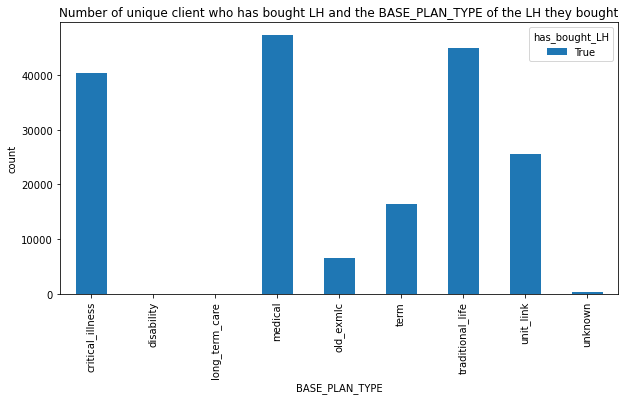

In [705]:
# count the number of unique client who has bought LH and the BASE_PLAN_TYPE of the LH they bought and plot a bar chart, add title and axis labels
Base_LH_df.groupby(["has_bought_LH", "BASE_PLAN_TYPE"])["modified_SECUITYNO"].nunique().reset_index(name="count").\
    pivot(index="BASE_PLAN_TYPE", columns="has_bought_LH", values="count").plot(kind="bar", figsize=(10, 5))
plt.title("Number of unique client who has bought LH and the BASE_PLAN_TYPE of the LH they bought")
plt.xlabel("BASE_PLAN_TYPE")
plt.ylabel("count")


Text(0, 0.5, 'count')

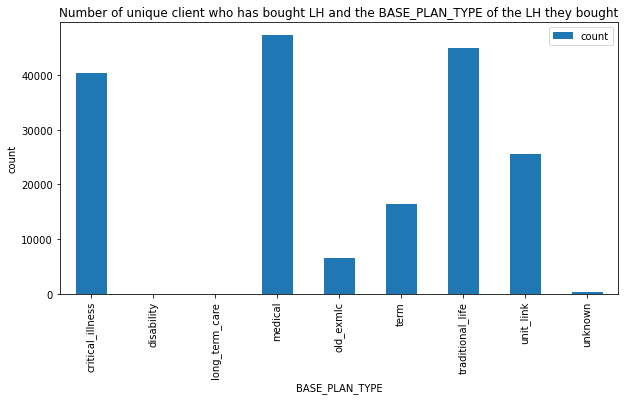

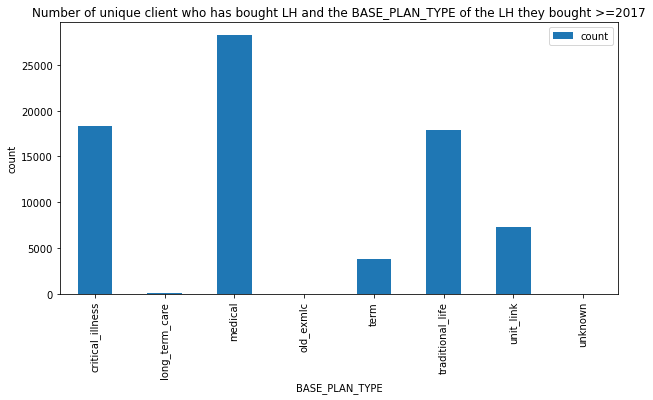

In [706]:
# get only the rows where has_bought_LH is True and then count the number of unique client who has bought LH and the BASE_PLAN_TYPE of the LH they bought and plot a bar chart, add title and axis labels
Base_LH_df[Base_LH_df["has_bought_LH"] == True].groupby(["BASE_PLAN_TYPE"])["modified_SECUITYNO"].nunique().reset_index(name="count").\
    plot(kind="bar", x="BASE_PLAN_TYPE", y="count", figsize=(10, 5))
plt.title("Number of unique client who has bought LH and the BASE_PLAN_TYPE of the LH they bought")
plt.xlabel("BASE_PLAN_TYPE")
plt.ylabel("count")


# get only the rows where has_bought_LH is True and SUBMIT_YEAR>=2017 and then count the number of unique client who has bought LH and the BASE_PLAN_TYPE of the LH they bought and plot a bar chart, add title and axis labels
Base_LH_df[(Base_LH_df["has_bought_LH"] == True) & (Base_LH_df["SUBMIT_YEAR"] >= 2017)].groupby(["BASE_PLAN_TYPE"])["modified_SECUITYNO"].nunique().reset_index(name="count").\
    plot(kind="bar", x="BASE_PLAN_TYPE", y="count", figsize=(10, 5))
plt.title("Number of unique client who has bought LH and the BASE_PLAN_TYPE of the LH they bought >=2017")
plt.xlabel("BASE_PLAN_TYPE")
plt.ylabel("count")

Text(0, 0.5, 'count')

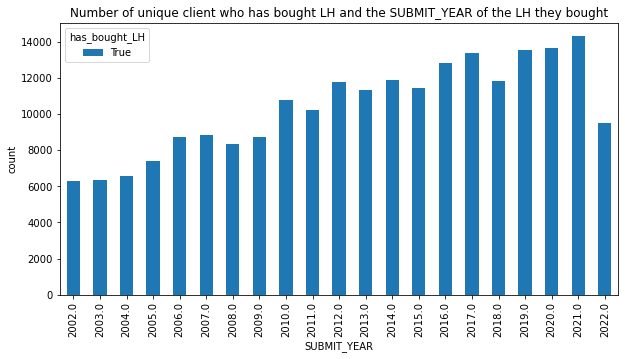

In [707]:
# count the number of unique client who has bought LH and the SUBMIT_YEAR of the LH they bought and plot a bar chart, add title and axis labels
Base_LH_df.groupby(["has_bought_LH", "SUBMIT_YEAR"])["modified_SECUITYNO"].nunique().reset_index(name="count").\
    pivot(index="SUBMIT_YEAR", columns="has_bought_LH", values="count").plot(kind="bar", figsize=(10, 5))
plt.title("Number of unique client who has bought LH and the SUBMIT_YEAR of the LH they bought")
plt.xlabel("SUBMIT_YEAR")
plt.ylabel("count")


Text(0, 0.5, 'count')

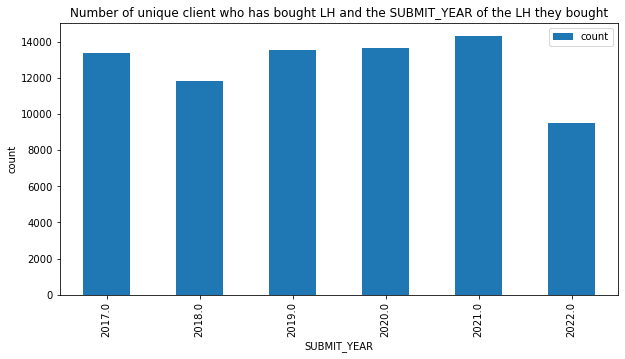

In [708]:
# get only the rows where has_bought_LH is True and SUBMIT_YEAR>=2017, then count the number of unique client who has bought LH and the SUBMIT_YEAR of the LH they bought and plot a bar chart, add title and axis labels
Base_LH_df[(Base_LH_df["has_bought_LH"] == True) & (Base_LH_df["SUBMIT_YEAR"] >= 2017)].groupby(["SUBMIT_YEAR"])["modified_SECUITYNO"].nunique().reset_index(name="count").\
    plot(kind="bar", x="SUBMIT_YEAR", y="count", figsize=(10, 5))
plt.title("Number of unique client who has bought LH and the SUBMIT_YEAR of the LH they bought")
plt.xlabel("SUBMIT_YEAR")
plt.ylabel("count")



(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, '2017.0'),
  Text(1, 0, '2018.0'),
  Text(2, 0, '2019.0'),
  Text(3, 0, '2020.0'),
  Text(4, 0, '2021.0'),
  Text(5, 0, '2022.0')])

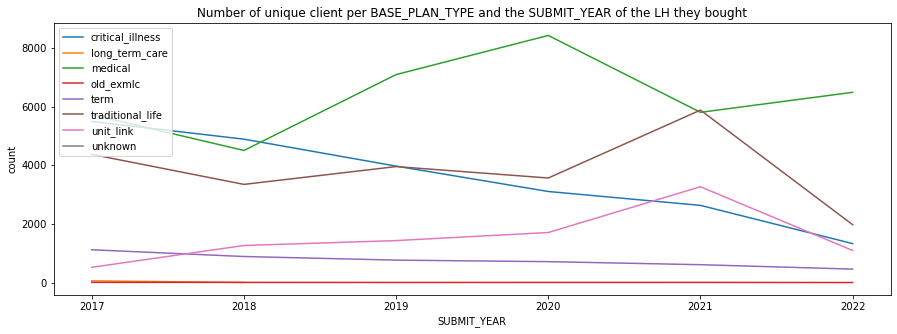

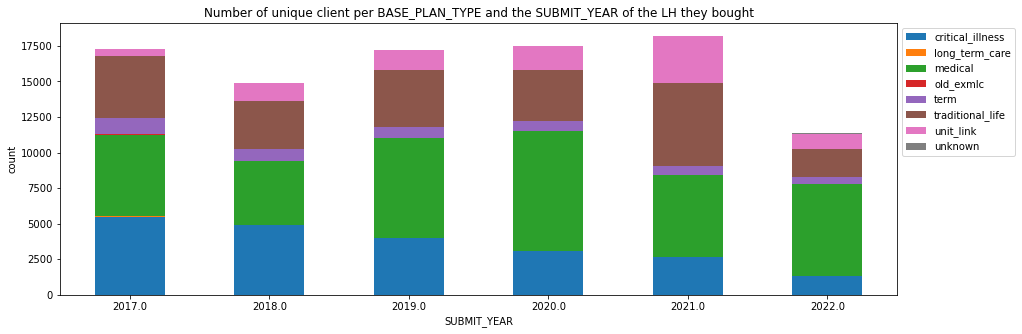

In [755]:
# get only the rows where has_bought_LH is True and SUBMIT_YEAR>=2017, then count the number of unique client per BASE_PLAN_TYPE and the SUBMIT_YEAR of the LH they bought and plot a line chart, add title and axis labels
Base_LH_df[(Base_LH_df["has_bought_LH"] == True) & (Base_LH_df["SUBMIT_YEAR"] >= 2017)].groupby(["BASE_PLAN_TYPE", "SUBMIT_YEAR"])["modified_SECUITYNO"].nunique().reset_index(name="count").\
    pivot(index="SUBMIT_YEAR", columns="BASE_PLAN_TYPE", values="count").plot(kind="line", figsize=(15, 5))
plt.title("Number of unique client per BASE_PLAN_TYPE and the SUBMIT_YEAR of the LH they bought")
plt.xlabel("SUBMIT_YEAR")
plt.ylabel("count")

# set legend location
plt.legend(loc="upper left")



# get only the rows where has_bought_LH is True and SUBMIT_YEAR>=2017, then count the number of unique client per BASE_PLAN_TYPE and the SUBMIT_YEAR of the LH they bought and plot a line chart, add title and axis labels
Base_LH_df[(Base_LH_df["has_bought_LH"] == True) & (Base_LH_df["SUBMIT_YEAR"] >= 2017)].groupby(["BASE_PLAN_TYPE", "SUBMIT_YEAR"])["modified_SECUITYNO"].nunique().reset_index(name="count").\
    pivot(index="SUBMIT_YEAR", columns="BASE_PLAN_TYPE", values="count").plot(kind="bar",stacked=True, figsize=(15, 5))
plt.title("Number of unique client per BASE_PLAN_TYPE and the SUBMIT_YEAR of the LH they bought")
plt.xlabel("SUBMIT_YEAR")
plt.ylabel("count")

# set legend location to out of the graph
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
# x axis labels rotation
plt.xticks(rotation=0)

## Occupation

In [710]:
Base_LH_df.columns

Index(['COWNNUM', 'contrnb', 'OCCDATE', 'CCDATE', 'channel', 'product',
       'plan1', 'plan2', 'plan3', 'duration', 'duration_grp', 'age_gp', 'gwp',
       'nb_clm', 'ult_clm', 'paymnt_g', 'period', 'if_pol', 'nbrn', 'CLTSEX',
       'modified_SECUITYNO', 'Single/Annual', 'OCCYEAR', 'CCYEAR', 'TimeRange',
       'period_year', 'POLICY_NO', 'SUBMIT_DATE', 'POLICY_DATE',
       'modified_owner_id', 'PLAN_CODE', 'BASE_PLAN_TYPE', 'SEX',
       'AGE_AT_ISSUE', 'BIRTH_DATE', 'MARITAL_STATUS', 'INCOME_LEVEL',
       'LIFE_SUM_INSURED', 'CLASS_CODE', 'ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR',
       'CURRENCY', 'has_bought_LH', 'SUBMIT_YEAR'],
      dtype='object')

In [711]:
# investigate MARRIAGE_STATUS
Base_LH_df["BIRTH_DATE"].unique()

array([      nan, 19800408., 19621028., ..., 20191204., 20180129.,
       19590105.])

## Travel Duration

Text(0, 0.5, 'count')

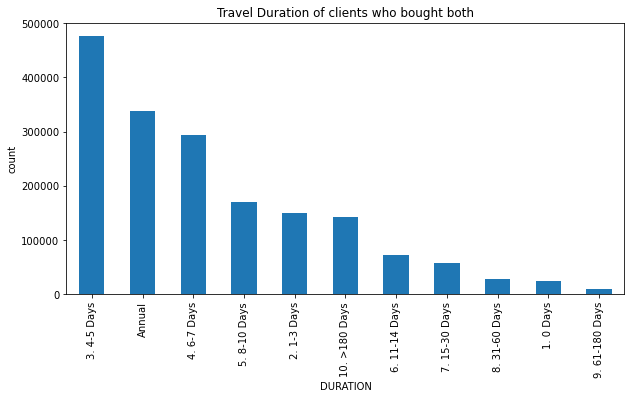

In [712]:
# get only rows where has_bought_LH is True, then plot the duration, add title and axis labels
Base_LH_df[(Base_LH_df["has_bought_LH"] == True)]["duration_grp"].value_counts().plot(kind="bar", figsize=(10, 5))
plt.title("Travel Duration of clients who bought both")
plt.xlabel("DURATION")
plt.ylabel("count")


C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_23712/2686230359.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Base_LH_df[(Base_LH_df["has_bought_LH"] == True)& (F_usefull_PCC['plan1']=='Single')].groupby(["CCYEAR"])["duration"].mean().reset_index(name="avg_duration").\


Text(0, 0.5, 'avg_duration')

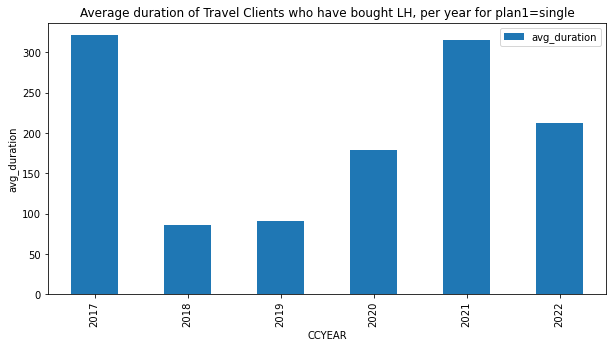

In [713]:
# get only rows where has_bought_LH is True, then plot the average duration per year per plan1, add title and axis labels
Base_LH_df[(Base_LH_df["has_bought_LH"] == True)& (F_usefull_PCC['plan1']=='Single')].groupby(["CCYEAR"])["duration"].mean().reset_index(name="avg_duration").\
    plot(kind="bar", x="CCYEAR", y="avg_duration", figsize=(10, 5))
plt.title("Average duration of Travel Clients who have bought LH, per year for plan1=single")
plt.xlabel("CCYEAR")
plt.ylabel("avg_duration")


## Travel Frequency

## Sum Insured (Life Plan Type)	


## Premium(?) (Health Plan)

## Age of first bought L&H

In [714]:
Base_LH_df.columns


Index(['COWNNUM', 'contrnb', 'OCCDATE', 'CCDATE', 'channel', 'product',
       'plan1', 'plan2', 'plan3', 'duration', 'duration_grp', 'age_gp', 'gwp',
       'nb_clm', 'ult_clm', 'paymnt_g', 'period', 'if_pol', 'nbrn', 'CLTSEX',
       'modified_SECUITYNO', 'Single/Annual', 'OCCYEAR', 'CCYEAR', 'TimeRange',
       'period_year', 'POLICY_NO', 'SUBMIT_DATE', 'POLICY_DATE',
       'modified_owner_id', 'PLAN_CODE', 'BASE_PLAN_TYPE', 'SEX',
       'AGE_AT_ISSUE', 'BIRTH_DATE', 'MARITAL_STATUS', 'INCOME_LEVEL',
       'LIFE_SUM_INSURED', 'CLASS_CODE', 'ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR',
       'CURRENCY', 'has_bought_LH', 'SUBMIT_YEAR'],
      dtype='object')

In [715]:
#count how many unique clients has AGE_AT_ISSUE 
Base_LH_df.groupby(["has_bought_LH", "AGE_AT_ISSUE"])["modified_SECUITYNO"].nunique()

has_bought_LH  AGE_AT_ISSUE
True           0.0             6865
               1.0             2328
               2.0             1959
               3.0             1838
               4.0             1644
                               ... 
               76.0              21
               77.0              28
               78.0              24
               79.0              23
               80.0              13
Name: modified_SECUITYNO, Length: 81, dtype: int64

In [716]:
# value count AGE_AT_ISSUE and dont dropna
Base_LH_df["AGE_AT_ISSUE"].value_counts(dropna=False)

NaN     2475434
0.0       58126
39.0      44374
40.0      42622
43.0      42066
         ...   
78.0        195
79.0        172
77.0        157
80.0        105
76.0        100
Name: AGE_AT_ISSUE, Length: 82, dtype: int64

In [717]:
# value count of BIRTH_DATE and sort
Base_LH_df["BIRTH_DATE"].value_counts(dropna=False).sort_index()

18550503.0          2
19271201.0          2
19281231.0          2
19321105.0          7
19321119.0          2
               ...   
20221007.0         40
20221012.0          7
20221017.0         10
20221021.0          2
NaN           2475434
Name: BIRTH_DATE, Length: 26278, dtype: int64

In [718]:
# create a new col "EARLIEST_SUBMIT_DATE" by extracting the earliest SUBMIT_DATE per client
# Base_LH_df["EARLIEST_SUBMIT_DATE"] = Base_LH_df.groupby("modified_SECUITYNO")["SUBMIT_DATE"].transform("min")
# find the age of the client at EARLIEST_SUBMIT_DATE 
# Base_LH_df["AGE_AT_EARLIEST_SUBMIT_DATE"] = Base_LH_df["EARLIEST_SUBMIT_DATE"].dt.year - Base_LH_df["BIRTH_DATE"].dt.year

In [719]:
# get only rows with has bought Lh,sort by SUBMIT_DATE using ascending, group by modified_SECUITYNO and get the first row per group then output to a df
First_Age=Base_LH_df[(Base_LH_df["has_bought_LH"] == True)].sort_values(by="SUBMIT_DATE", ascending=True).groupby("modified_SECUITYNO").first().reset_index()

In [720]:
First_Age[(First_Age["modified_SECUITYNO"] == 'E740327')]

,modified_SECUITYNO,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age_gp,gwp,nb_clm,ult_clm,paymnt_g,period,if_pol,nbrn,CLTSEX,Single/Annual,OCCYEAR,CCYEAR,TimeRange,period_year,POLICY_NO,SUBMIT_DATE,POLICY_DATE,modified_owner_id,PLAN_CODE,BASE_PLAN_TYPE,SEX,AGE_AT_ISSUE,BIRTH_DATE,MARITAL_STATUS,INCOME_LEVEL,LIFE_SUM_INSURED,CLASS_CODE,ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR,CURRENCY,has_bought_LH,SUBMIT_YEAR
15247,E740327,2868171,25861838,2019-11-27,2019-11-27,HSBC,Single Trip 2018,Single,Asia,Basic,5.0,3. 4-5 Days,5. Age 51 - 60,34.88,0.0,0.0,0.0,2019-11-27,0.0,NB,M,None,2019,2019,1.PreCovid,2019,303-6248312,2012-04-20,2012-04-20,E740327,MES2,medical,M,49.0,19621028.0,M,,0.0,1,4169.0,HKD,True,2012.0


In [721]:

Base_LH_df[(Base_LH_df["has_bought_LH"] == True)][["modified_SECUITYNO","has_bought_LH","SUBMIT_DATE","POLICY_DATE","AGE_AT_ISSUE"]].head(10)


,modified_SECUITYNO,has_bought_LH,SUBMIT_DATE,POLICY_DATE,AGE_AT_ISSUE
2,Z059410,True,2018-03-27,2018-03-26,37.0
3,Z059410,True,2018-03-27,2018-03-26,37.0
70,E740327,True,2012-04-20,2012-04-20,49.0
71,E740327,True,2020-08-10,2020-08-14,20.0
72,E740327,True,2012-04-20,2012-04-20,49.0
73,E740327,True,2020-08-10,2020-08-14,20.0
112,D641326,True,2009-08-04,2009-08-03,42.0
113,D641326,True,2009-08-04,2009-08-03,42.0
126,G451542,True,2018-04-03,2018-03-28,47.0
127,G451542,True,2010-11-22,2010-12-28,40.0


Text(0, 0.5, 'count')

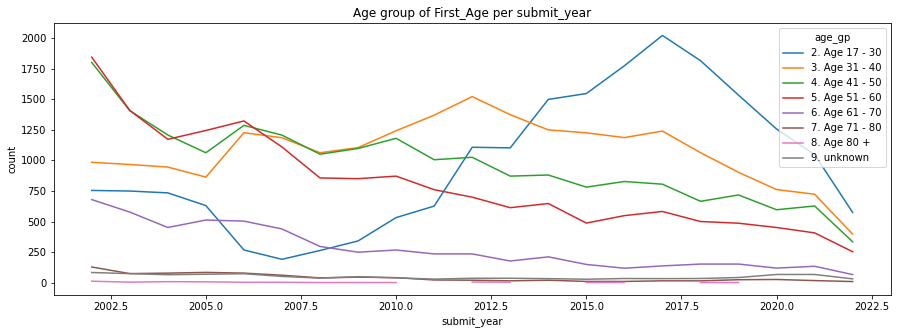

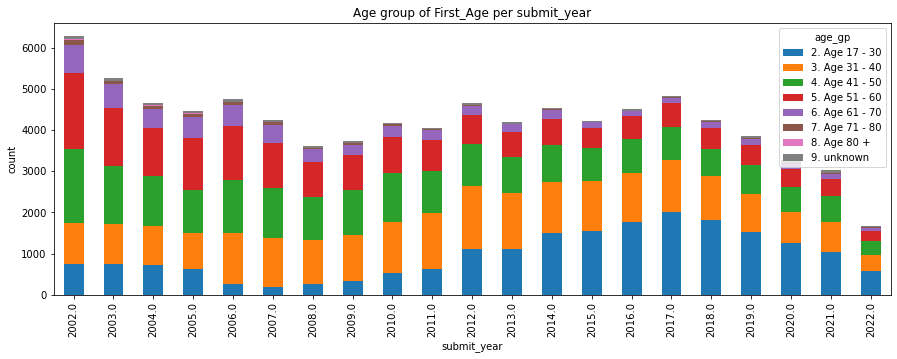

In [745]:
# plot age_gp of First_Age per submit_year and add title and axis labels from 
First_Age.groupby(["SUBMIT_YEAR", "age_gp"])["modified_SECUITYNO"].nunique().reset_index(name="count").\
    pivot(index="SUBMIT_YEAR", columns="age_gp", values="count").plot(kind="line", figsize=(15, 5))
plt.title("Age group of First_Age per submit_year")
plt.xlabel("submit_year")
plt.ylabel("count")


# plot a stacked bar chat of age_gp of First_Age per submit_year and add title and axis labels from 
First_Age.groupby(["SUBMIT_YEAR", "age_gp"])["modified_SECUITYNO"].nunique().reset_index(name="count").\
    pivot(index="SUBMIT_YEAR", columns="age_gp", values="count").plot(kind="bar", stacked=True, figsize=(15, 5))
plt.title("Age group of First_Age per submit_year")
plt.xlabel("submit_year")
plt.ylabel("count")

Text(0, 0.5, 'count')

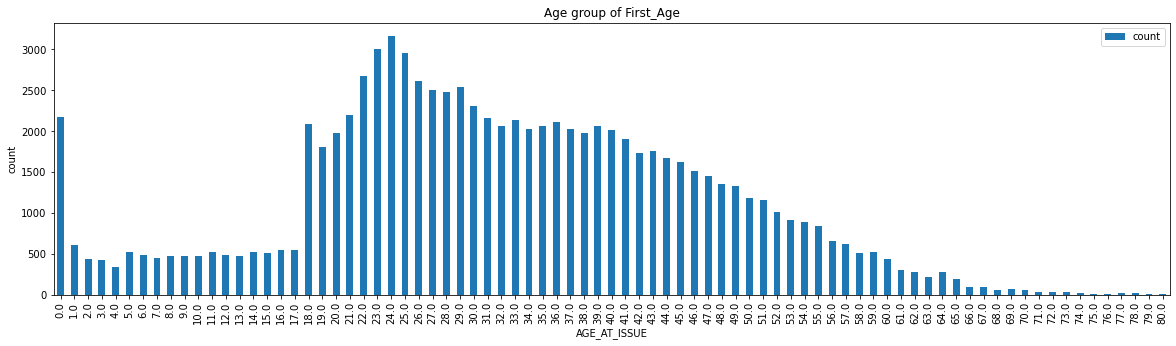

In [744]:
# plot age_gp of First_Age and add title and axis labels from 
First_Age.groupby(["AGE_AT_ISSUE"])["modified_SECUITYNO"].nunique().reset_index(name="count").\
    plot(kind="bar", x="AGE_AT_ISSUE", y="count", figsize=(20, 5))
plt.title("Age group of First_Age")
plt.xlabel("AGE_AT_ISSUE")
plt.ylabel("count")



Text(0, 0.5, 'count')

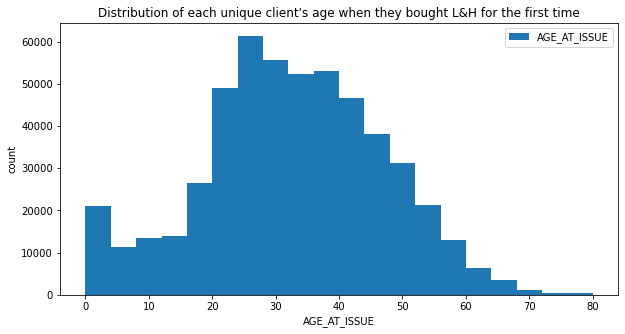

In [724]:
# plot the distribution of each unique client's age when they bought L&H for the first time, find earliest submit_date for each client and then calculate the age by AGE_AT_ISSUE, add title and axis labels
Base_LH_df.groupby(["modified_SECUITYNO"])["SUBMIT_DATE"].min().reset_index(name="earliest_submit_date").\
    merge(Base_LH_df, left_on=["modified_SECUITYNO", "earliest_submit_date"], right_on=["modified_SECUITYNO", "SUBMIT_DATE"])[["AGE_AT_ISSUE"]].plot(kind="hist", bins=20, figsize=(10, 5))
plt.title("Distribution of each unique client's age when they bought L&H for the first time")
plt.xlabel("AGE_AT_ISSUE")
plt.ylabel("count")



## Gender Ratio

In [725]:
# value count of  and dont dropna then normalize
Base_LH_df["SEX"].value_counts(dropna=False, normalize=True)


NaN    0.583924
F      0.251110
M      0.164966
Name: SEX, dtype: float64

In [726]:
# how many unqiue clients who has has_bought=NaN
Base_LH_df[Base_LH_df["SEX"].isnull()]["modified_SECUITYNO"].nunique()

441035

In [727]:
#how many unqiue clients
Base_LH_df["modified_SECUITYNO"].nunique()

529267

In [728]:
(441035/529267)*100

83.3293970717993

In [729]:
# change col name to   
Base_LH_df.rename(columns={"SEX": "GEN"}, inplace=True)

Text(0, 0.5, 'count')

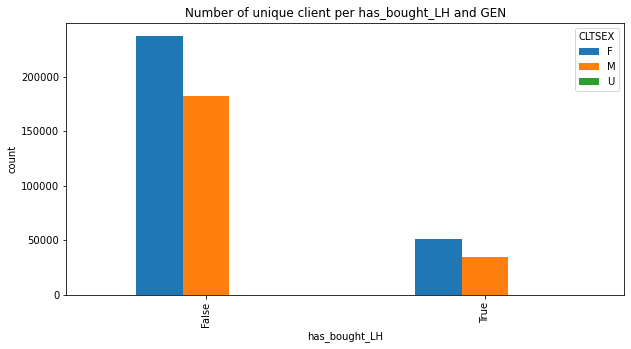

In [730]:
# calculate the unique clients per has_bought_LH per GEN then plot the result
Base_LH_df.groupby(["has_bought_LH", "CLTSEX"])["modified_SECUITYNO"].nunique().reset_index(name="count").\
    pivot(index="has_bought_LH", columns="CLTSEX", values="count").plot(kind="bar", figsize=(10, 5))
plt.title("Number of unique client per has_bought_LH and GEN")
plt.xlabel("has_bought_LH")
plt.ylabel("count")


In [731]:
#value count has_bought_LH 
Base_LH_df["has_bought_LH"].value_counts(dropna=False)

False    2475434
True     1763872
Name: has_bought_LH, dtype: int64

# premiun

In [732]:
CURRENCY_CHANGE_RATE_TO_HKD={
    "AUD": 6.66,
    "CAD": 6.66,
    "CHF": 5.71,
    "EUR": 8.0,
    "USD": 8.0,
    "SGD": 5.0,
    "NZD":4.44,
    "GBP":13.33
}

In [733]:
# generate a new col using the CURRENCY_CHANGE_RATE_TO_HKD dict and CURRENCY and ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR
# if CURRENCY is in the dict, then use the value in the dict to multiply ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR
# if CURRENCY is not in the dict, then use 1 to multiply ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR
Base_LH_df["ANNUAL_PREM_HKD"] = Base_LH_df["CURRENCY"].apply(lambda x: CURRENCY_CHANGE_RATE_TO_HKD[x] if x in CURRENCY_CHANGE_RATE_TO_HKD else 1) * Base_LH_df["ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR"]


In [734]:
# show Base_LH_df["ANNUAL_PREM_HKD"] and ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR
Base_LH_df[["ANNUAL_PREM_HKD", "CURRENCY","ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR"]].sample(10)

,ANNUAL_PREM_HKD,CURRENCY,ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR
1467595,NaN,NaN,NaN
732627,NaN,NaN,NaN
3030934,NaN,NaN,NaN
1675133,NaN,NaN,NaN
756427,NaN,NaN,NaN
2990257,38114.50,HKD,38114.50
1130573,NaN,NaN,NaN
952108,5119.00,HKD,5119.00
877483,16685.44,USD,2085.68
1951026,50000.00,HKD,50000.00


Text(0, 0.5, 'ANNUAL_PREM_HKD')

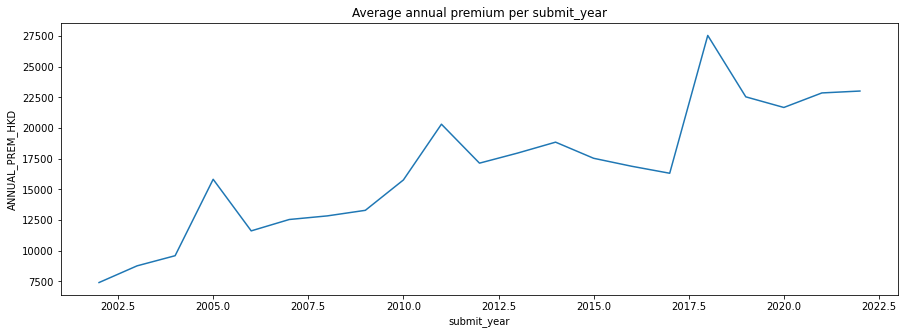

In [735]:
#get only rows with has bought Lh
#group by POLICY_NO and ANNUAL_PREM_HKD then drop duplicates
#plot the ANNUAL_PREM_HKD per SUBMIT_YEAR
Base_LH_df[(Base_LH_df["has_bought_LH"] == True)].groupby(["POLICY_NO", "ANNUAL_PREM_HKD"])["SUBMIT_YEAR"].first().reset_index().\
    drop_duplicates(subset=["POLICY_NO", "ANNUAL_PREM_HKD"]).groupby("SUBMIT_YEAR")["ANNUAL_PREM_HKD"].mean().plot(kind="line", figsize=(15, 5))
plt.title("Average annual premium per submit_year")
plt.xlabel("submit_year")
plt.ylabel("ANNUAL_PREM_HKD")



In [736]:
Base_LH_df.columns

Index(['COWNNUM', 'contrnb', 'OCCDATE', 'CCDATE', 'channel', 'product',
       'plan1', 'plan2', 'plan3', 'duration', 'duration_grp', 'age_gp', 'gwp',
       'nb_clm', 'ult_clm', 'paymnt_g', 'period', 'if_pol', 'nbrn', 'CLTSEX',
       'modified_SECUITYNO', 'Single/Annual', 'OCCYEAR', 'CCYEAR', 'TimeRange',
       'period_year', 'POLICY_NO', 'SUBMIT_DATE', 'POLICY_DATE',
       'modified_owner_id', 'PLAN_CODE', 'BASE_PLAN_TYPE', 'GEN',
       'AGE_AT_ISSUE', 'BIRTH_DATE', 'MARITAL_STATUS', 'INCOME_LEVEL',
       'LIFE_SUM_INSURED', 'CLASS_CODE', 'ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR',
       'CURRENCY', 'has_bought_LH', 'SUBMIT_YEAR', 'ANNUAL_PREM_HKD'],
      dtype='object')

Text(0, 0.5, 'ANNUAL_PREM_HKD')

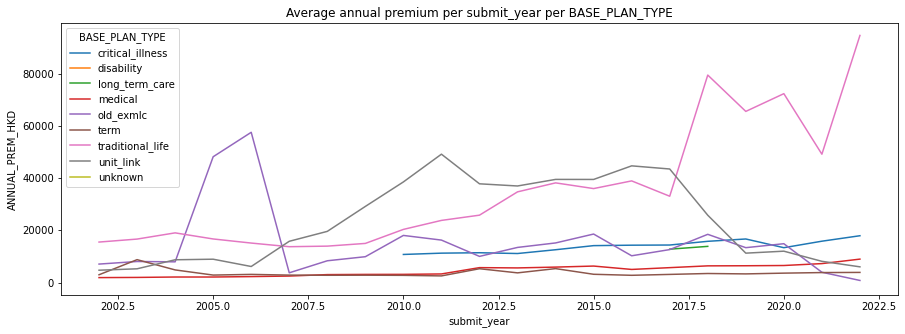

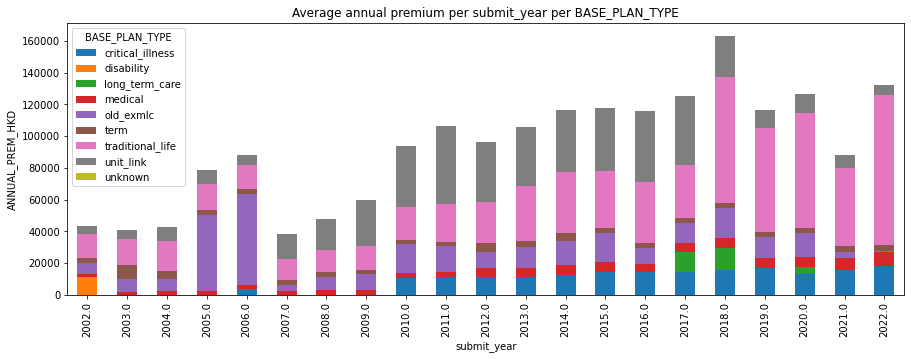

In [746]:
#get only rows with has bought Lh

#group by POLICY_NO and ANNUAL_PREM_HKD then drop duplicates
#plot the ANNUAL_PREM_HKD per SUBMIT_YEAR per BASE_PLAN_TYPE
premium=Base_LH_df[(Base_LH_df["has_bought_LH"] == True)].drop_duplicates(subset=["POLICY_NO", "ANNUAL_PREM_HKD"]).groupby(["SUBMIT_YEAR", "BASE_PLAN_TYPE"])["ANNUAL_PREM_HKD"].mean().reset_index().pivot(index="SUBMIT_YEAR", columns="BASE_PLAN_TYPE", values="ANNUAL_PREM_HKD").plot(kind="line", figsize=(15, 5))
plt.title("Average annual premium per submit_year per BASE_PLAN_TYPE")
plt.xlabel("submit_year")
plt.ylabel("ANNUAL_PREM_HKD")

#get only rows with has bought Lh

#group by POLICY_NO and ANNUAL_PREM_HKD then drop duplicates
#plot the ANNUAL_PREM_HKD per SUBMIT_YEAR per BASE_PLAN_TYPE
premium=Base_LH_df[(Base_LH_df["has_bought_LH"] == True)].drop_duplicates(subset=["POLICY_NO", "ANNUAL_PREM_HKD"]).groupby(["SUBMIT_YEAR", "BASE_PLAN_TYPE"])["ANNUAL_PREM_HKD"].mean().reset_index().pivot(index="SUBMIT_YEAR", columns="BASE_PLAN_TYPE", values="ANNUAL_PREM_HKD").plot(kind="bar",stacked=True, figsize=(15, 5))
plt.title("Average annual premium per submit_year per BASE_PLAN_TYPE")
plt.xlabel("submit_year")
plt.ylabel("ANNUAL_PREM_HKD")

(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, '2. Age 17 - 30'),
  Text(1, 0, '3. Age 31 - 40'),
  Text(2, 0, '4. Age 41 - 50'),
  Text(3, 0, '5. Age 51 - 60'),
  Text(4, 0, '6. Age 61 - 70'),
  Text(5, 0, '7. Age 71 - 80'),
  Text(6, 0, '8. Age 80 +'),
  Text(7, 0, '9. unknown')])

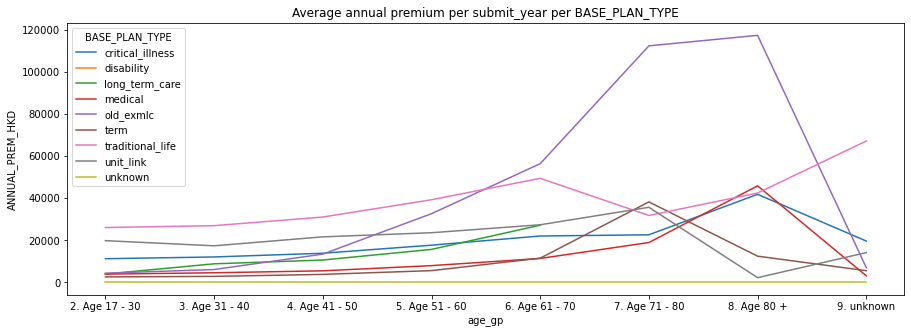

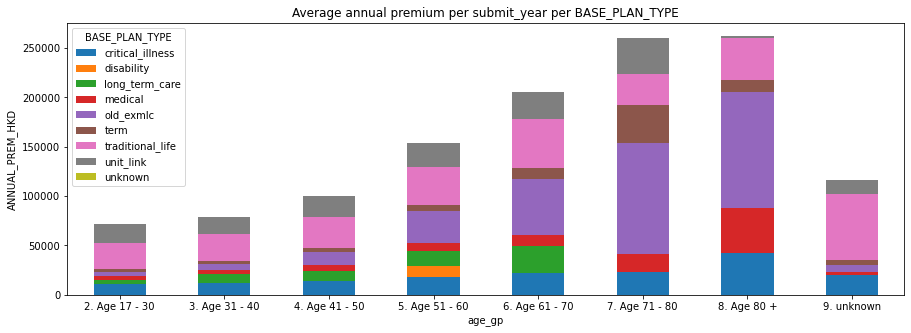

In [750]:
premium=Base_LH_df[(Base_LH_df["has_bought_LH"] == True)].drop_duplicates(subset=["POLICY_NO", "ANNUAL_PREM_HKD"]).groupby(["age_gp", "BASE_PLAN_TYPE"])["ANNUAL_PREM_HKD"].mean().reset_index().pivot(index="age_gp", columns="BASE_PLAN_TYPE", values="ANNUAL_PREM_HKD").plot(kind="line", figsize=(15, 5))
plt.title("Average annual premium per submit_year per BASE_PLAN_TYPE")
plt.xlabel("age_gp")
plt.ylabel("ANNUAL_PREM_HKD")

#make a stacked bar chart of the graph
premium=Base_LH_df[(Base_LH_df["has_bought_LH"] == True)].drop_duplicates(subset=["POLICY_NO", "ANNUAL_PREM_HKD"]).groupby(["age_gp", "BASE_PLAN_TYPE"])["ANNUAL_PREM_HKD"].mean().reset_index().pivot(index="age_gp", columns="BASE_PLAN_TYPE", values="ANNUAL_PREM_HKD").plot(kind="bar", figsize=(15, 5), stacked=True)
plt.title("Average annual premium per submit_year per BASE_PLAN_TYPE")
plt.xlabel("age_gp")
plt.ylabel("ANNUAL_PREM_HKD")
# rotate the x axis labels
plt.xticks(rotation=0)

Text(0, 0.5, 'ANNUAL_PREM_HKD')

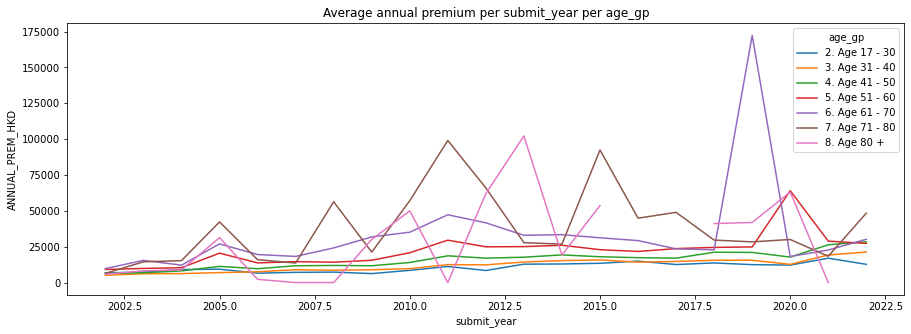

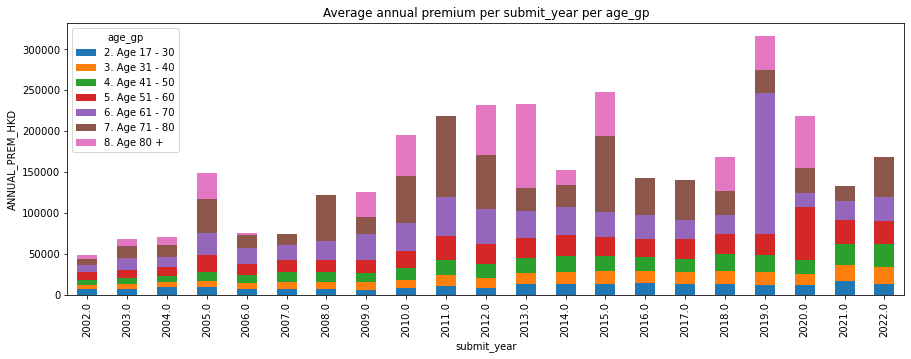

In [747]:
Base_LH_df[(Base_LH_df["has_bought_LH"] == True)&(Base_LH_df["age_gp"] != "9. unknown")].drop_duplicates(subset=["POLICY_NO", "ANNUAL_PREM_HKD"]).groupby(["SUBMIT_YEAR", "age_gp"])["ANNUAL_PREM_HKD"].mean().reset_index().pivot(index="SUBMIT_YEAR", columns="age_gp", values="ANNUAL_PREM_HKD").plot(kind="line", figsize=(15, 5))
plt.title("Average annual premium per submit_year per age_gp")
plt.xlabel("submit_year")
plt.ylabel("ANNUAL_PREM_HKD")


Base_LH_df[(Base_LH_df["has_bought_LH"] == True)&(Base_LH_df["age_gp"] != "9. unknown")].drop_duplicates(subset=["POLICY_NO", "ANNUAL_PREM_HKD"]).groupby(["SUBMIT_YEAR", "age_gp"])["ANNUAL_PREM_HKD"].mean().reset_index().pivot(index="SUBMIT_YEAR", columns="age_gp", values="ANNUAL_PREM_HKD").plot(kind="bar", stacked=True,figsize=(15, 5))
plt.title("Average annual premium per submit_year per age_gp")
plt.xlabel("submit_year")
plt.ylabel("ANNUAL_PREM_HKD")


Text(0, 0.5, 'ANNUAL_PREM_HKD')

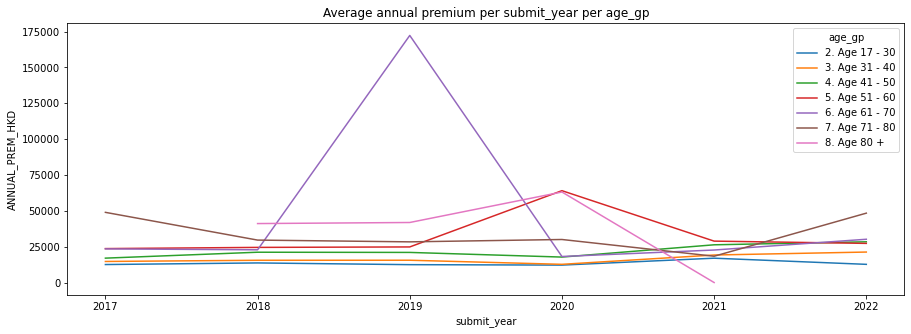

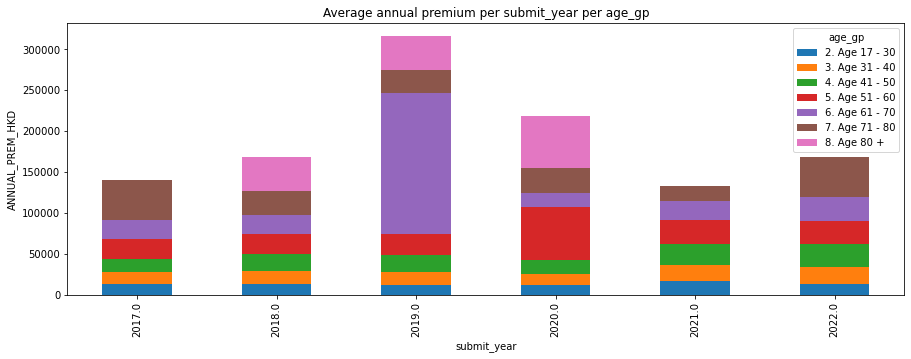

In [748]:
Base_LH_df[(Base_LH_df['SUBMIT_YEAR']>=2017)&(Base_LH_df["has_bought_LH"] == True)&(Base_LH_df["age_gp"] != "9. unknown")].drop_duplicates(subset=["POLICY_NO", "ANNUAL_PREM_HKD"]).groupby(["SUBMIT_YEAR", "age_gp"])["ANNUAL_PREM_HKD"].mean().reset_index().pivot(index="SUBMIT_YEAR", columns="age_gp", values="ANNUAL_PREM_HKD").plot(kind="line", figsize=(15, 5))
plt.title("Average annual premium per submit_year per age_gp")
plt.xlabel("submit_year")
plt.ylabel("ANNUAL_PREM_HKD")


Base_LH_df[(Base_LH_df['SUBMIT_YEAR']>=2017)&(Base_LH_df["has_bought_LH"] == True)&(Base_LH_df["age_gp"] != "9. unknown")].drop_duplicates(subset=["POLICY_NO", "ANNUAL_PREM_HKD"]).groupby(["SUBMIT_YEAR", "age_gp"])["ANNUAL_PREM_HKD"].mean().reset_index().pivot(index="SUBMIT_YEAR", columns="age_gp", values="ANNUAL_PREM_HKD").plot(kind="bar",stacked=True, figsize=(15, 5))
plt.title("Average annual premium per submit_year per age_gp")
plt.xlabel("submit_year")
plt.ylabel("ANNUAL_PREM_HKD")

In [741]:
#value count age_gp
Base_LH_df["age_gp"].value_counts(dropna=False)

# print all unique values of age_gp
Base_LH_df["age_gp"].unique()



array(['6. Age 61 - 70', '3. Age 31 - 40', '4. Age 41 - 50',
       '5. Age 51 - 60', '2. Age 17 - 30', '7. Age 71 - 80',
       '8. Age 80 +', '9. unknown', '1. Less than 16'], dtype=object)

In [742]:
Base_LH_df[Base_LH_df["age_gp"] == "unknown "]

,COWNNUM,contrnb,OCCDATE,CCDATE,channel,product,plan1,plan2,plan3,duration,duration_grp,age_gp,gwp,nb_clm,ult_clm,paymnt_g,period,if_pol,nbrn,CLTSEX,modified_SECUITYNO,Single/Annual,OCCYEAR,CCYEAR,TimeRange,period_year,POLICY_NO,SUBMIT_DATE,POLICY_DATE,modified_owner_id,PLAN_CODE,BASE_PLAN_TYPE,GEN,AGE_AT_ISSUE,BIRTH_DATE,MARITAL_STATUS,INCOME_LEVEL,LIFE_SUM_INSURED,CLASS_CODE,ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR,CURRENCY,has_bought_LH,SUBMIT_YEAR,ANNUAL_PREM_HKD


Text(0, 0.5, 'ANNUAL_PREM_HKD')

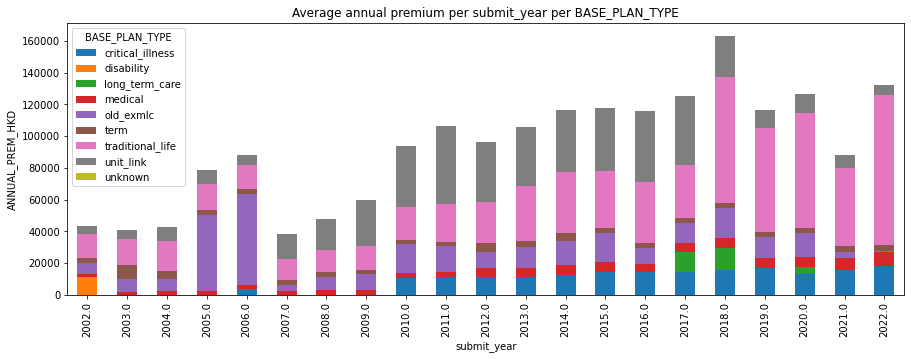

In [749]:
premium=Base_LH_df[(Base_LH_df["has_bought_LH"] == True)].drop_duplicates(subset=["POLICY_NO", "ANNUAL_PREM_HKD"]).groupby(["SUBMIT_YEAR", "BASE_PLAN_TYPE"])["ANNUAL_PREM_HKD"].mean().reset_index().pivot(index="SUBMIT_YEAR", columns="BASE_PLAN_TYPE", values="ANNUAL_PREM_HKD").plot(kind="bar",stacked=True, figsize=(15, 5))
plt.title("Average annual premium per submit_year per BASE_PLAN_TYPE")
plt.xlabel("submit_year")
plt.ylabel("ANNUAL_PREM_HKD")

In [559]:
# get all unique value of TimeRange and put ot TR as a list
TR = Base_LH_df["TimeRange"].unique().tolist()
TR

['1.PreCovid', '2.Covid', '3.PostCovid']

# Frequency

In [ ]:
# generate a table with col "Annual" "Single"

In [562]:
# TIME_RANGE_MIN = 20020101 
# TIME_RANGE_MAX = 20181231
#get OCCDATE >= 20200101 and OCCDATE <= 20221031
# DF_in_desired_timerage=F_usefull_PCC[(F_usefull_PCC["OCCDATE"]>= pd.to_datetime(TIME_RANGE_MIN, format="%Y%m%d")) & (F_usefull_PCC["OCCDATE"]<= pd.to_datetime(TIME_RANGE_MAX, format="%Y%m%d"))]

for timeRange in TR:
# get TimeRange = timeRange from F_usefull_PCC

    print("For timerange: ", timeRange, "")
    DF_in_desired_timerage=Base_LH_df[(Base_LH_df["TimeRange"]==timeRange)][(Base_LH_df["has_bought_LH"] == True)]
    # DF_in_desired_timerage['OCCDATE'].sort_values()
    # DF_in_desired_timerage['modified_SECUITYNO'].value_counts()
    # DF_in_desired_timerage[DF_in_desired_timerage['modified_SECUITYNO']=='C640656']
    # DF_in_desired_timerage.groupby(['modified_SECUITYNO'])["contrnb"].nunique().sort_values().tail(20)
    #each person have how many unique order in last 3 month
    DUMMY_ID=['unknown','A123456','F123456']
    # show column 'modified_SECUITYNO' and 'age' only, while filter out rows where 'modified_SECUITYNO' is in DUMMY_ID
    # DF_in_desired_timerage[DF_in_desired_timerage['modified_SECUITYNO'].isin(DUMMY_ID)][['modified_SECUITYNO','age']].value_counts()
    # DF_in_desired_timerage.groupby(['modified_SECUITYNO'])["contrnb"].nunique().sort_values()
    z = DF_in_desired_timerage.groupby(['modified_SECUITYNO'])["contrnb"].nunique().sort_values()
    z1=z.to_dict()
    len(z1)
    DF_in_desired_timerageID=DF_in_desired_timerage[['modified_SECUITYNO','plan1','contrnb']].copy()
    # DF_in_desired_timerageID
    # #group by modified_SECUITYNO and plan1 and count the number of unique contrnb
    # DF_in_desired_timerageID.groupby(['modified_SECUITYNO','plan1'])["contrnb"].nunique().sort_values()
    # #group by modified_SECUITYNO and plan1 and count the number of unique contrnb then output the result as a new df
    # DF_in_desired_timerageID.groupby(['modified_SECUITYNO','plan1'])["contrnb"].nunique().sort_values().to_frame().reset_index()

    DF_in_desired_timerageID1=DF_in_desired_timerageID.groupby(['modified_SECUITYNO','plan1'])["contrnb"].nunique().sort_values().to_frame().reset_index()

    # rename contrnb to Number_unique_contrnb in DF_in_desired_timerageID1
    DF_in_desired_timerageID1.rename(columns={'contrnb': 'Number_unique_contrnb'}, inplace=True)
    DF_in_desired_timerageID1
    # drop rows where 'modified_SECUITYNO' is in DUMMY_ID in DF_in_desired_timerageID1 
    DF_in_desired_timerageID1=DF_in_desired_timerageID1[~DF_in_desired_timerageID1['modified_SECUITYNO'].isin(DUMMY_ID)]

    # DF_in_desired_timerageID1['Number_unique_contrnb'].value_counts().sort_values()
    #368 ppl have bought 1 order in last 3 month
    #1 ppl have bought 3 order in 2020-20221001 
    # Number of unique modified_SECUITYNO in DF_in_desired_timerageID1 group by plan1
    # DF_in_desired_timerageID1.groupby(['plan1'])["modified_SECUITYNO"].nunique().sort_values()
    # Get rows where 'Number_unique_contrnb' is >= 1 in DF_in_desired_timerageID1
    # Atleast1times=DF_in_desired_timerageID1[DF_in_desired_timerageID1['Number_unique_contrnb']>=1]
    # Number of unique modified_SECUITYNO in Atleast1times group by plan1
    # Atleast1times.groupby(['plan1'])["modified_SECUITYNO"].nunique().sort_values()

    for i in range(4):
        AtLeatThisTimes=i
        print(f'AtLeatThisTimes={AtLeatThisTimes}')
        Atleasttimes=DF_in_desired_timerageID1[DF_in_desired_timerageID1['Number_unique_contrnb']>=AtLeatThisTimes]
        print(Atleasttimes.groupby(['plan1'])["modified_SECUITYNO"].nunique().sort_values())
        # AtLeatThisTimes=AtLeatThisTimes+1

For timerange:  1.PreCovid 


C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_23712/81687262.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  DF_in_desired_timerage=Base_LH_df[(Base_LH_df["TimeRange"]==timeRange)][(Base_LH_df["has_bought_LH"] == True)]


AtLeatThisTimes=0
plan1
Annual    11057
Single    78576
Name: modified_SECUITYNO, dtype: int64
AtLeatThisTimes=1
plan1
Annual    11057
Single    78576
Name: modified_SECUITYNO, dtype: int64
AtLeatThisTimes=2
plan1
Annual     2269
Single    43719
Name: modified_SECUITYNO, dtype: int64
AtLeatThisTimes=3
plan1
Annual      397
Single    28571
Name: modified_SECUITYNO, dtype: int64
For timerange:  2.Covid 
AtLeatThisTimes=0
plan1
Annual    1626
Single    4788
Name: modified_SECUITYNO, dtype: int64
AtLeatThisTimes=1
plan1
Annual    1626
Single    4788
Name: modified_SECUITYNO, dtype: int64
AtLeatThisTimes=2
plan1
Annual    126
Single    524
Name: modified_SECUITYNO, dtype: int64
AtLeatThisTimes=3
plan1
Annual    10
Single    79
Name: modified_SECUITYNO, dtype: int64
For timerange:  3.PostCovid 
AtLeatThisTimes=0
plan1
Annual    118
Single    393
Name: modified_SECUITYNO, dtype: int64
AtLeatThisTimes=1
plan1
Annual    118
Single    393
Name: modified_SECUITYNO, dtype: int64
AtLeatThisTimes=2
